Реализовать с помощью `Numpy` класс `MyMLP`, моделирующий работу полносвязной нейронной сети.

Реализуемый класс должен

1. Поддерживать создание любого числа слоев с любым числом нейронов. Тип инициализации весов не регламентируется.
2. Обеспечивать выбор следующих функции активации в рамках каждого слоя: `ReLU`, `sigmoid`, `linear`.
3. Поддерживать решение задачи классификации и регрессии (выбор соответствующего лосса, в том числе для задачи многоклассовой классификации).
4. В процессе обучения использовать самостоятельно реализованный механизм обратного распространения (вывод формул в формате markdown) для применения градиентного и стохастического градиентного спусков (с выбором размера батча)
5. Поддерживать использование `l1`, `l2` и `l1l2` регуляризаций.

Самостоятельно выбрать наборы данных (классификация и регрессия). Провести эксперименты (различные конфигурации сети: количество слоев, нейронов, функции активации, скорость обучения и тп. — минимум 5 различных конфигураций) и сравнить результаты работы (оценка качества модели + время обучения и инференса) реализованного класса `MyMLP` со следующими моделям (в одинаковых конфигурациях):

*   MLPClassifier/MLPRegressor из sklearn
*   TensorFlow
*   Keras
*   PyTorch

Результат представить в виде .ipynb блокнота, содержащего весь необходимый код и визуализации сравнения реализаций для рассмотренных конфигураций.


# Ход работы

## Создание функций и их производных

Ниже создаются функции активаций и потерь, а также их производные для вычислений град. спуска в модели

Ф-ии активации:

In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)



def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)



def linear(x):
    return x

def linear_derivative(x):
    return np.ones_like(x)



def softmax(x):
    shifted_x = x - np.max(x, axis=1, keepdims=True)
    exp_values = np.exp(shifted_x)

    return exp_values / np.sum(exp_values, axis=1, keepdims=True)

Ф-ии потерь

In [ ]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mse_derivative(y_true, y_pred):
    return 2 * (y_pred - y_true) / y_true.shape[0]



def binary_cross_entropy(y_true, y_pred):

    epsilon = 1e-15

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )

    return loss

def binary_cross_entropy_derivative(y_true, y_pred):

    epsilon = 1e-15

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    return (
        (y_pred - y_true) /
        (y_pred * (1 - y_pred) * y_true.shape[0])
    )



def categorical_cross_entropy(y_true, y_pred):

    epsilon = 1e-15

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        np.sum(y_true * np.log(y_pred), axis=1)
    )

    return loss

def categorical_cross_entropy_derivative(y_true, y_pred):
    return (y_pred - y_true) / y_true.shape[0]

Ф-ии регуляризаций:

In [ ]:
def l1_penalty(weights, lambda_):
    return lambda_ * np.sum(np.abs(weights))

def l1_derivative(weights, lambda_):
    return lambda_ * np.sign(weights)


def l2_penalty(weights, lambda_):
    return lambda_ * np.sum(weights ** 2)

def l2_derivative(weights, lambda_):
    return 2 * lambda_ * weights

Словари для удобного доступа к функциям по строке параметра

In [ ]:
ACTIVATIONS = {
    "sigmoid": sigmoid,
    "relu": relu,
    "linear": linear,
    "softmax": softmax
}

ACTIVATION_DERIVATIVES = {
    "sigmoid": sigmoid_derivative,
    "relu": relu_derivative,
    "linear": linear_derivative
}

LOSSES = {
    "mse": mse_loss,
    "binary_cross_entropy": binary_cross_entropy,
    "categorical_cross_entropy": categorical_cross_entropy
}

LOSS_DERIVATIVES = {
    "mse": mse_derivative,
    "binary_cross_entropy": binary_cross_entropy_derivative,
    "categorical_cross_entropy": categorical_cross_entropy_derivative
}

Функции инициализации весовС чтобы не инициализировать одними значениями. xavier будем использовать, когда ф-ии активаций -- сигмодиы, he -- иначе

In [ ]:
def xavier_init(input_size, output_size):

    limit = np.sqrt(6 / (input_size + output_size))

    return np.random.uniform(
        -limit,
        limit,
        (input_size, output_size)
    )

def he_init(input_size, output_size):

    std = np.sqrt(2 / input_size)

    return np.random.randn(input_size, output_size) * std

## Реализация класса MyMLP

Ниже приведена моя реализация MyMLP, поддерживающая разные число нейронов, ф-ии активации, методы регуляризации и использующая свою реализацию backpropagnation.

В коде старался делать комментарии к неочевидным моментам

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    f1_score
)


class MyMLP:

    # заполняем поля объекта и в конце инициализируем параметры одним из двух методов: he или xavier
    def __init__(
        self,
        layer_sizes,
        activations,
        loss,
        learning_rate=0.01,
        epochs=100,
        batch_size=32,
        regularization=None,
        lambda_=0.001,
        weight_init="he",
        gradient_clip=None,
        early_stopping=False,
        patience=10,
        random_state=42
    ):

        np.random.seed(random_state)

        self.layer_sizes = layer_sizes
        self.activations = activations

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size

        self.loss_name = loss

        self.regularization = regularization
        self.lambda_ = lambda_

        self.weight_init = weight_init

        self.gradient_clip = gradient_clip

        self.early_stopping = early_stopping
        self.patience = patience

        self.train_loss_history = []
        self.val_loss_history = []


        self.loss_function = LOSSES[self.loss_name]

        self.loss_derivative = LOSS_DERIVATIVES[
            self.loss_name
        ]

        self.weights = []
        self.biases = []

        self._initialize_parameters()


    # ф-ия инфиализации весов, для каждого уровня инициализируем веса нужной функцией, в зависимости от ф-ии активации
    def _initialize_parameters(self):

        for i in range(len(self.layer_sizes) - 1):

            input_size = self.layer_sizes[i]
            output_size = self.layer_sizes[i + 1]

            if self.weight_init == "xavier":

                W = xavier_init(
                    input_size,
                    output_size
                )

            elif self.weight_init == "he":

                W = he_init(
                    input_size,
                    output_size
                )


            b = np.zeros((1, output_size))

            self.weights.append(W)
            self.biases.append(b)



    # ф-ия прямого распространения: на каждом уровне домножаем на веса
    def _forward(self, X):

        self.z_values = []
        self.a_values = [X]

        A = X

        for layer_idx in range(len(self.weights)):

            W = self.weights[layer_idx]
            b = self.biases[layer_idx]

            Z = np.dot(A, W) + b

            self.z_values.append(Z)

            activation_name = self.activations[
                layer_idx
            ]

            activation_function = ACTIVATIONS[
                activation_name
            ]

            A = activation_function(Z)

            self.a_values.append(A)

        return A


    # подсчет ф-ии потерь с учетом регуляризации
    def _compute_regularization_loss(self):

        reg_loss = 0

        for W in self.weights:

            if self.regularization == "l1":

                reg_loss += l1_penalty(
                    W,
                    self.lambda_
                )

            elif self.regularization == "l2":

                reg_loss += l2_penalty(
                    W,
                    self.lambda_
                )

            elif self.regularization == "l1l2":

                reg_loss += (
                    l1_penalty(W, self.lambda_) +
                    l2_penalty(W, self.lambda_)
                )

        return reg_loss

    # подсчет ф-ии потерь
    def _compute_loss(
        self,
        y_true,
        y_pred
    ):

        data_loss = self.loss_function(
            y_true,
            y_pred
        )

        reg_loss = (
            self._compute_regularization_loss()
        )

        return data_loss + reg_loss


    # ф-ия обратно распространения ошибки
    def _backward(
        self,
        y_true,
        y_pred
    ):

        self.dW = []
        self.db = []

        dA = self.loss_derivative(
            y_true,
            y_pred
        )

        # идем в обратном порядке по слоям
        for layer_idx in reversed(
            range(len(self.weights))
        ):

            A_prev = self.a_values[layer_idx]

            Z = self.z_values[layer_idx]

            W = self.weights[layer_idx]

            activation_name = self.activations[
                layer_idx
            ]


            is_output_layer = (layer_idx == len(self.weights) - 1)

            # отдельно обрабатываем кейсы сигмоида + бинарная кросс-экнтропия и Softmax + категориальная кросс-ентропия
            # чтобы избежать численных потерь при вычислении простых производных из комбинаций
            if (
                is_output_layer and
                activation_name == "sigmoid" and
                self.loss_name == "binary_cross_entropy"
            ):

                dZ = y_pred - y_true

            elif (
                is_output_layer and
                activation_name == "softmax" and
                self.loss_name ==
                "categorical_cross_entropy"
            ):

                dZ = y_pred - y_true
            # обработка обычной кейса
            else:
                activation_derivative = (
                    ACTIVATION_DERIVATIVES[
                        activation_name
                    ]
                )

                dZ = (
                    dA *
                    activation_derivative(Z)
                )

            dW = np.dot(A_prev.T, dZ)

            db = np.sum(
                dZ,
                axis=0,
                keepdims=True
            )

            # добавляем регуляризацию
            if self.regularization == "l1":

                dW += l1_derivative(
                    W,
                    self.lambda_
                )

            elif self.regularization == "l2":

                dW += l2_derivative(
                    W,
                    self.lambda_
                )

            elif self.regularization == "l1l2":

                dW += (
                    l1_derivative(W, self.lambda_) +
                    l2_derivative(W, self.lambda_)
                )

            # клиппим градиеннт воизбежание сильных всплесков
            if self.gradient_clip is not None:

                dW = np.clip(
                    dW,
                    -self.gradient_clip,
                    self.gradient_clip
                )

                db = np.clip(
                    db,
                    -self.gradient_clip,
                    self.gradient_clip
                )

            self.dW.insert(0, dW)
            self.db.insert(0, db)

            dA = np.dot(dZ, W.T)


    # ф-ия обновления весов
    def _update_parameters(self):

        for i in range(len(self.weights)):

            self.weights[i] -= (
                self.learning_rate *
                self.dW[i]
            )

            self.biases[i] -= (
                self.learning_rate *
                self.db[i]
            )


    # само обучение по эпохам
    def fit(
        self,
        X_train,
        y_train,
        X_val=None,
        y_val=None,
        verbose=True
    ):

        n_samples = X_train.shape[0]

        best_val_loss = np.inf
        patience_counter = 0

        for epoch in range(self.epochs):

            # перемешиваем данные в эпохе
            indices = np.random.permutation(
                n_samples
            )

            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            epoch_loss = 0

            # идем по данным мини-батчами полным циклом: прямой ход, лосс, и обратно распространение, обновление весов
            for start_idx in range(
                0,
                n_samples,
                self.batch_size
            ):

                end_idx = (
                    start_idx +
                    self.batch_size
                )

                X_batch = X_shuffled[
                    start_idx:end_idx
                ]

                y_batch = y_shuffled[
                    start_idx:end_idx
                ]

                # Forward
                y_pred = self._forward(X_batch)

                # Loss
                batch_loss = self._compute_loss(
                    y_batch,
                    y_pred
                )

                epoch_loss += batch_loss

                # Backpropagation
                self._backward(
                    y_batch,
                    y_pred
                )

                # Update
                self._update_parameters()

            epoch_loss /= (
                n_samples /
                self.batch_size
            )

            self.train_loss_history.append(
                epoch_loss
            )

            # подсчет метрик на валидации
            if (
                X_val is not None and
                y_val is not None
            ):

                val_pred = self._forward(X_val)

                val_loss = self._compute_loss(
                    y_val,
                    val_pred
                )

                self.val_loss_history.append(
                    val_loss
                )


            # вывод статистик эпохи
            if verbose and (
                epoch % 10 == 0 or
                epoch == self.epochs - 1
            ):

                if (
                    X_val is not None and
                    y_val is not None
                ):

                    print(
                        f"Epoch {epoch+1}/{self.epochs} | "
                        f"Train Loss: {epoch_loss:.6f} | "
                        f"Val Loss: {val_loss:.6f}"
                    )

                else:

                    print(
                        f"Epoch {epoch+1}/{self.epochs} | "
                        f"Loss: {epoch_loss:.6f}"
                    )


    #ф-ия предикта: просто прямой ход
    def predict_proba(self, X):
        return self._forward(X)

    # предикт для разных задач
    def predict(self, X):

        y_pred = self._forward(X)

        # Regression
        if self.loss_name == "mse":
            return y_pred

        # Binary classification
        elif self.loss_name == "binary_cross_entropy":
            return (y_pred > 0.5).astype(int)

        # Multiclass classification
        elif (
            self.loss_name ==
            "categorical_cross_entropy"
        ):
            return np.argmax(y_pred, axis=1)


    # ф-ия подсчета качества для рахзных задач
    def evaluate(
        self,
        X,
        y,
        metric="auto"
    ):

        y_pred = self.predict(X)

        # Regression
        if self.loss_name == "mse":

            return {
                "MAE": mean_absolute_error(
                    y,
                    y_pred
                ),

                "RMSE": np.sqrt(
                    mean_squared_error(
                        y,
                        y_pred
                    )
                ),

                "R2": r2_score(
                    y,
                    y_pred
                )
            }

        # Binary classification
        elif (
            self.loss_name ==
            "binary_cross_entropy"
        ):

            return {
                "Accuracy": accuracy_score(
                    y,
                    y_pred
                ),

                "F1": f1_score(
                    y,
                    y_pred
                )
            }

        # Multiclass classification
        elif (
            self.loss_name ==
            "categorical_cross_entropy"
        ):

            y_true_labels = np.argmax(
                y,
                axis=1
            )

            return {
                "Accuracy": accuracy_score(
                    y_true_labels,
                    y_pred
                ),

                "F1_macro": f1_score(
                    y_true_labels,
                    y_pred,
                    average="macro"
                )
            }


    # саммари по модели
    def summary(self):

        print("\nMyMLP Architecture\n")

        for i in range(len(self.weights)):

            print(
                f"Layer {i+1}: "
                f"{self.layer_sizes[i]} -> "
                f"{self.layer_sizes[i+1]} | "
                f"Activation: "
                f"{self.activations[i]}"
            )

        print(f"\nLoss: {self.loss_name}")

## Сравнение для multiclass classification

Загружаем датасет MNIST, будем проверять на нем.

Нормируем данные, разбиваем на трейн и тест

In [ ]:
import time
import pandas as pd
import numpy as np

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

digits = load_digits()

X = digits.data
y = digits.target

scaler = StandardScaler()

X = scaler.fit_transform(X)

encoder = OneHotEncoder(sparse_output=False)

y_onehot = encoder.fit_transform(
    y.reshape(-1, 1)
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_onehot,
    test_size=0.2,
    random_state=42
)

Конфиги для сравнения моделей (5 конфигов, как в задании)

In [ ]:
configs = [

    {
        "name": "mc_config_1",
        "layer_sizes": [64, 32, 10],
        "activations": ["relu", "softmax"],
        "learning_rate": 0.01,
        "batch_size": 32
    },

    {
        "name": "mc_config_2",
        "layer_sizes": [64, 64, 10],
        "activations": ["relu", "softmax"],
        "learning_rate": 0.001,
        "batch_size": 32
    },

    {
        "name": "mc_config_3",
        "layer_sizes": [64, 128, 64, 10],
        "activations": ["relu", "relu", "softmax"],
        "learning_rate": 0.001,
        "batch_size": 64
    },

    {
        "name": "mc_config_4",
        "layer_sizes": [64, 64, 32, 10],
        "activations": ["sigmoid", "sigmoid", "softmax"],
        "learning_rate": 0.001,
        "batch_size": 32
    },

    {
        "name": "mc_config_5",
        "layer_sizes": [64, 256, 128, 10],
        "activations": ["relu", "relu", "softmax"],
        "learning_rate": 0.0005,
        "batch_size": 128
    }
]

### Обучение и предикт с помощью MyMLP

In [ ]:
results = []

for config in configs:

    print("=" * 50)
    print(config["name"])
    print("=" * 50)

    # Создание модели
    model = MyMLP(
        layer_sizes=config["layer_sizes"],
        activations=config["activations"],
        loss="categorical_cross_entropy",
        learning_rate=config["learning_rate"],
        epochs=100,
        batch_size=config["batch_size"],
        regularization="l2",
        lambda_=0.0001,
        patience=10,
        gradient_clip=5
    )

    # Трейн
    start_train = time.time()

    model.fit(
        X_train,
        y_train,
        X_val=X_test,
        y_val=y_test,
        verbose=False
    )

    end_train = time.time()

    training_time = end_train - start_train

    # Подсчет инференса
    start_infer = time.time()

    y_pred = model.predict(X_test)

    end_infer = time.time()

    inference_time = end_infer - start_infer


    metrics = model.evaluate(X_test, y_test)


    # сохранение результатов
    results.append({
        "framework": "MyMLP",

        "config_name": config["name"],

        "task_type": "multiclass classification",

        "layer_sizes": config["layer_sizes"],

        "activations": config["activations"],

        "learning_rate": config["learning_rate"],

        "batch_size": config["batch_size"],

        "train_time_sec": training_time,

        "inference_time_sec": inference_time,

        "accuracy": metrics["Accuracy"],

        "f1_macro": metrics["F1_macro"],

        "train_loss_history": model.train_loss_history,

        "val_loss_history": model.val_loss_history,

        "model": model
    })

mc_config_1
mc_config_2
mc_config_3
mc_config_4
mc_config_5


Датафрейм результатов для MyMLP

In [ ]:
results_df = pd.DataFrame(results)

results_df

,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,accuracy,f1_macro,train_loss_history,val_loss_history,model
0,MyMLP,mc_config_1,multiclass classification,"[64, 32, 10]","[relu, softmax]",0.0100,32,3.208032,0.000437,0.975000,0.975335,"[0.7459768006978461, 0.20726514597062012, 0.12...","[0.2544986058227495, 0.1555009952363294, 0.130...",<__main__.MyMLP object at 0x7c7e4140d550>
1,MyMLP,mc_config_2,multiclass classification,"[64, 64, 10]","[relu, softmax]",0.0010,32,4.524543,0.026847,0.969444,0.968862,"[1.692469759543653, 0.8559850852908534, 0.5852...","[1.0682163801211855, 0.6799232832616182, 0.516...",<__main__.MyMLP object at 0x7c7e35a61880>
2,MyMLP,mc_config_3,multiclass classification,"[64, 128, 64, 10]","[relu, relu, softmax]",0.0010,64,7.123330,0.000989,0.980556,0.980538,"[1.5330529110375735, 0.5822872743988782, 0.365...","[0.823218706835264, 0.47887477267263345, 0.361...",<__main__.MyMLP object at 0x7c7e3fc23380>
3,MyMLP,mc_config_4,multiclass classification,"[64, 64, 32, 10]","[sigmoid, sigmoid, softmax]",0.0010,32,3.070440,0.001243,0.958333,0.957651,"[2.396962964103694, 2.267431518175779, 2.21960...","[2.2818407478790887, 2.234248992912008, 2.1958...",<__main__.MyMLP object at 0x7c7e3cad6930>
4,MyMLP,mc_config_5,multiclass classification,"[64, 256, 128, 10]","[relu, relu, softmax]",0.0005,128,6.553926,0.002048,0.980556,0.981253,"[1.7437210333882764, 0.8081681168392133, 0.529...","[0.915259031817005, 0.5754930723852574, 0.4441...",<__main__.MyMLP object at 0x7c7e3d482a80>


### Обучение и предикт с помощью sklearn MLPClassifier

НИже парсим конфиги в параметры sklearn, обучаем и предсказыаем

In [ ]:
import time
import pandas as pd
import numpy as np

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

sklearn_results = []

for config in configs:

    print("=" * 50)
    print(config["name"])
    print("=" * 50)


    layer_sizes = config["layer_sizes"]

    activations = config["activations"]

    learning_rate = config["learning_rate"]

    batch_size = config["batch_size"]

    hidden_layers = tuple(
        layer_sizes[1:-1]
    )


    # ренейминг под sklearn
    activation_mapping = {
      "sigmoid": "logistic",
      "linear": "identity",
      "relu": "relu"
    }
    hidden_activation = activation_mapping[
      activations[0]
  ]

    model = MLPClassifier(

        hidden_layer_sizes=hidden_layers,

        activation=hidden_activation,

        learning_rate_init=learning_rate,

        batch_size=batch_size,

        max_iter=100,

        random_state=42
    )



    start_train = time.time()

    model.fit(
        X_train,
        y_train
    )

    end_train = time.time()

    training_time = (
        end_train - start_train
    )


    start_infer = time.time()

    y_pred = model.predict(X_test)

    end_infer = time.time()

    inference_time = (
        end_infer - start_infer
    )


    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    f1_macro = f1_score(
        y_test,
        y_pred,
        average="macro"
    )


    sklearn_results.append({

        "framework": "sklearn",

        "config_name": config["name"],

        "task_type": "multiclass_classification",

        "layer_sizes": layer_sizes,

        "activations": activations,

        "learning_rate": learning_rate,

        "batch_size": batch_size,

        "train_time_sec": training_time,

        "inference_time_sec": inference_time,

        "accuracy": accuracy,

        "f1_macro": f1_macro,

        "train_loss_history": model.loss_curve_,

        "model": model
    })


sklearn_results_df = pd.DataFrame(
    sklearn_results
)

sklearn_results_df

mc_config_1
mc_config_2


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


mc_config_3
mc_config_4


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


mc_config_5


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,accuracy,f1_macro,train_loss_history,model
0,sklearn,mc_config_1,multiclass_classification,"[64, 32, 10]","[relu, softmax]",0.0100,32,1.546216,0.007913,0.955556,0.971935,"[2.1922608513022137, 0.4444720963835922, 0.254...","MLPClassifier(batch_size=32, hidden_layer_size..."
1,sklearn,mc_config_2,multiclass_classification,"[64, 64, 10]","[relu, softmax]",0.0010,32,5.538249,0.002950,0.963889,0.979478,"[5.028899940283788, 2.49774990830243, 1.596512...","MLPClassifier(batch_size=32, hidden_layer_size..."
2,sklearn,mc_config_3,multiclass_classification,"[64, 128, 64, 10]","[relu, relu, softmax]",0.0010,64,10.570011,0.002766,0.963889,0.972885,"[5.490519019087797, 2.6218714394514477, 1.6636...","MLPClassifier(batch_size=64, hidden_layer_size..."
3,sklearn,mc_config_4,multiclass_classification,"[64, 64, 32, 10]","[sigmoid, sigmoid, softmax]",0.0010,32,3.610785,0.001493,0.961111,0.970612,"[5.564397521061931, 3.7143069108584337, 3.2475...","MLPClassifier(activation='logistic', batch_siz..."
4,sklearn,mc_config_5,multiclass_classification,"[64, 256, 128, 10]","[relu, relu, softmax]",0.0005,128,4.436064,0.002527,0.963889,0.976240,"[6.149478821913863, 3.805900666259771, 2.62574...","MLPClassifier(batch_size=128, hidden_layer_siz..."


### Обучение и предикт с помощью tensorflow

Т.к. keras -- это по сути апи tensorflow, то сравнивать буду только с  tensorflow

In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

tensorflow_results = []

# парсим конфиги под формат библиотеки
for config in configs:

    print("=" * 50)
    print(config["name"])
    print("=" * 50)

    layer_sizes = config["layer_sizes"]

    activations = config["activations"]

    learning_rate = config["learning_rate"]

    batch_size = config["batch_size"]

    model = Sequential()

    hidden_layers = layer_sizes[1:-1]

    hidden_activations = activations[:-1]


    for i, (neurons, activation) in enumerate(
        zip(
            hidden_layers,
            hidden_activations
        )
    ):

        if i == 0:

            model.add(
                Dense(
                    neurons,
                    activation=activation,
                    input_shape=(
                        X_train.shape[1],
                    )
                )
            )

        else:

            model.add(
                Dense(
                    neurons,
                    activation=activation
                )
            )


    output_neurons = layer_sizes[-1]

    output_activation = activations[-1]


    model.add(
        Dense(
            output_neurons,
            activation=output_activation
        )
    )

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss="categorical_crossentropy",

        metrics=["accuracy"]
    )


    # трейн
    start_train = time.time()

    history = model.fit(

        X_train,

        y_train,

        epochs=100,

        batch_size=batch_size,

        validation_split=0.2,

        verbose=0
    )

    end_train = time.time()

    training_time = (
        end_train - start_train
    )


    # предикт
    start_infer = time.time()

    y_pred_probs = model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        y_pred_probs,
        axis=1
    )

    end_infer = time.time()

    inference_time = (
        end_infer - start_infer
    )


    y_true = np.argmax(
        y_test,
        axis=1
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    tensorflow_results.append({

        "framework": "tensorflow",

        "config_name": config["name"],

        "task_type": "multiclass_classification",

        "layer_sizes": layer_sizes,

        "activations": activations,

        "learning_rate": learning_rate,

        "batch_size": batch_size,

        "train_time_sec": training_time,

        "inference_time_sec": inference_time,

        "accuracy": accuracy,

        "f1_macro": f1_macro,

        "train_loss_history":
            history.history["loss"],

        "val_loss_history":
            history.history["val_loss"],

        "model": model
    })

tensorflow_results_df = pd.DataFrame(
    tensorflow_results
)

tensorflow_results_df

mc_config_1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mc_config_2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mc_config_3


...

mc_config_4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mc_config_5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,accuracy,f1_macro,train_loss_history,val_loss_history,model
0,tensorflow,mc_config_1,multiclass_classification,"[64, 32, 10]","[relu, softmax]",0.0100,32,22.392322,0.142531,0.972222,0.972934,"[0.9099739193916321, 0.15785740315914154, 0.08...","[0.42275843024253845, 0.33710938692092896, 0.3...","<Sequential name=sequential_27, built=True>"
1,tensorflow,mc_config_2,multiclass_classification,"[64, 64, 10]","[relu, softmax]",0.0010,32,18.719008,0.200394,0.975000,0.974874,"[2.0119457244873047, 1.1223307847976685, 0.702...","[1.5303502082824707, 0.9218838214874268, 0.641...","<Sequential name=sequential_28, built=True>"
2,tensorflow,mc_config_3,multiclass_classification,"[64, 128, 64, 10]","[relu, relu, softmax]",0.0010,64,22.791666,46.979387,0.977778,0.979078,"[1.8799868822097778, 1.0412101745605469, 0.523...","[1.4757614135742188, 0.812207818031311, 0.4903...","<Sequential name=sequential_29, built=True>"
3,tensorflow,mc_config_4,multiclass_classification,"[64, 64, 32, 10]","[sigmoid, sigmoid, softmax]",0.0010,32,30.023436,0.159762,0.966667,0.967350,"[2.2934799194335938, 2.0731794834136963, 1.891...","[2.1595921516418457, 1.9913830757141113, 1.806...","<Sequential name=sequential_30, built=True>"
4,tensorflow,mc_config_5,multiclass_classification,"[64, 256, 128, 10]","[relu, relu, softmax]",0.0005,128,14.777091,0.158463,0.980556,0.981111,"[2.126096725463867, 1.535187005996704, 1.07790...","[1.7693227529525757, 1.2768983840942383, 0.894...","<Sequential name=sequential_31, built=True>"


### Обучение и предикт с помощью PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

pytorch_results = []

# в силу особенностей библиотеки было проще собрать свой класс для парсинга конфигов
class TorchMLP(nn.Module):

    def __init__(
        self,
        layer_sizes,
        activations
    ):

        super().__init__()

        layers = []

        # Hidden layers
        for i in range(
            len(layer_sizes) - 2
        ):

            input_size = layer_sizes[i]

            output_size = layer_sizes[i + 1]

            activation = activations[i]

            # Linear layer
            layers.append(
                nn.Linear(
                    input_size,
                    output_size
                )
            )

            # Activation
            if activation == "relu":

                layers.append(nn.ReLU())

            elif activation == "sigmoid":

                layers.append(nn.Sigmoid())

        # Output layer
        layers.append(
            nn.Linear(
                layer_sizes[-2],
                layer_sizes[-1]
            )
        )

        self.network = nn.Sequential(
            *layers
        )


    def forward(self, x):
        return self.network(x)


# еперевод в тензоры
X_train_tensor = torch.FloatTensor(
    X_train
).to(device)

X_test_tensor = torch.FloatTensor(
    X_test
).to(device)


y_train_labels = np.argmax(
    y_train,
    axis=1
)

y_test_labels = np.argmax(
    y_test,
    axis=1
)

y_train_tensor = torch.LongTensor(
    y_train_labels
).to(device)


# обучение и предикт
for config in configs:

    print("=" * 50)
    print(config["name"])
    print("=" * 50)


    layer_sizes = config["layer_sizes"]

    activations = config["activations"]

    learning_rate = config["learning_rate"]

    batch_size = config["batch_size"]

    model = TorchMLP(
        layer_sizes,
        activations
    ).to(device)


    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    dataset = torch.utils.data.TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    train_loss_history = []

    train_accuracy_history = []

    start_train = time.time()


    for epoch in range(100):

        model.train()

        epoch_loss = 0

        correct = 0

        total = 0


        for batch_X, batch_y in dataloader:

            optimizer.zero_grad()

            # Forward
            outputs = model(batch_X)

            # Loss
            loss = criterion(
                outputs,
                batch_y
            )

            # Backward
            loss.backward()

            # Update
            optimizer.step()

            epoch_loss += loss.item()

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == batch_y
            ).sum().item()

            total += batch_y.size(0)


        avg_loss = (
            epoch_loss / len(dataloader)
        )

        accuracy = correct / total

        train_loss_history.append(
            avg_loss
        )

        train_accuracy_history.append(
            accuracy
        )


    end_train = time.time()

    training_time = (
        end_train - start_train
    )


    # предикт
    model.eval()

    start_infer = time.time()

    with torch.no_grad():

        outputs = model(
            X_test_tensor
        )

        y_pred = torch.argmax(
            outputs,
            dim=1
        ).cpu().numpy()

    end_infer = time.time()

    inference_time = (
        end_infer - start_infer
    )


    accuracy = accuracy_score(
        y_test_labels,
        y_pred
    )

    f1_macro = f1_score(
        y_test_labels,
        y_pred,
        average="macro"
    )



    pytorch_results.append({

        "framework": "pytorch",

        "config_name": config["name"],

        "task_type":
            "multiclass_classification",

        "layer_sizes": layer_sizes,

        "activations": activations,

        "learning_rate": learning_rate,

        "batch_size": batch_size,

        "train_time_sec": training_time,

        "inference_time_sec":
            inference_time,

        "accuracy": accuracy,

        "f1_macro": f1_macro,

        "train_loss_history":
            train_loss_history,

        "model": model
    })


pytorch_results_df = pd.DataFrame(
    pytorch_results
)


pytorch_results_df

mc_config_1
mc_config_2
mc_config_3
mc_config_4
mc_config_5


,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,accuracy,f1_macro,train_loss_history,model
0,pytorch,mc_config_1,multiclass_classification,"[64, 32, 10]","[relu, softmax]",0.0100,32,12.324831,0.000296,0.980556,0.981066,"[0.7898996194203695, 0.1265138040814135, 0.059...",TorchMLP(\n (network): Sequential(\n (0): ...
1,pytorch,mc_config_2,multiclass_classification,"[64, 64, 10]","[relu, softmax]",0.0010,32,9.299304,0.000301,0.972222,0.972828,"[1.9851850509643554, 1.1693675504790413, 0.619...",TorchMLP(\n (network): Sequential(\n (0): ...
2,pytorch,mc_config_3,multiclass_classification,"[64, 128, 64, 10]","[relu, relu, softmax]",0.0010,64,4.112735,0.000621,0.980556,0.981317,"[2.051209885141124, 1.2693406654440837, 0.5471...",TorchMLP(\n (network): Sequential(\n (0): ...
3,pytorch,mc_config_4,multiclass_classification,"[64, 64, 32, 10]","[sigmoid, sigmoid, softmax]",0.0010,32,8.727978,0.000359,0.975000,0.974810,"[2.2898273679945205, 2.1928838782840305, 2.036...",TorchMLP(\n (network): Sequential(\n (0): ...
4,pytorch,mc_config_5,multiclass_classification,"[64, 256, 128, 10]","[relu, relu, softmax]",0.0005,128,3.781460,0.001305,0.975000,0.976751,"[2.147788147131602, 1.7806935211022694, 1.3633...",TorchMLP(\n (network): Sequential(\n (0): ...


### Собираем все тесты в один и строим графики

In [ ]:
multiclass_results_df = pd.concat([results_df, sklearn_results_df, tensorflow_results_df, pytorch_results_df])

multiclass_results_df

,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,accuracy,f1_macro,train_loss_history,val_loss_history,model
0,MyMLP,mc_config_1,multiclass classification,"[64, 32, 10]","[relu, softmax]",0.0100,32,3.208032,0.000437,0.975000,0.975335,"[0.7459768006978461, 0.20726514597062012, 0.12...","[0.2544986058227495, 0.1555009952363294, 0.130...",<__main__.MyMLP object at 0x7c7e4140d550>
1,MyMLP,mc_config_2,multiclass classification,"[64, 64, 10]","[relu, softmax]",0.0010,32,4.524543,0.026847,0.969444,0.968862,"[1.692469759543653, 0.8559850852908534, 0.5852...","[1.0682163801211855, 0.6799232832616182, 0.516...",<__main__.MyMLP object at 0x7c7e35a61880>
2,MyMLP,mc_config_3,multiclass classification,"[64, 128, 64, 10]","[relu, relu, softmax]",0.0010,64,7.123330,0.000989,0.980556,0.980538,"[1.5330529110375735, 0.5822872743988782, 0.365...","[0.823218706835264, 0.47887477267263345, 0.361...",<__main__.MyMLP object at 0x7c7e3fc23380>
3,MyMLP,mc_config_4,multiclass classification,"[64, 64, 32, 10]","[sigmoid, sigmoid, softmax]",0.0010,32,3.070440,0.001243,0.958333,0.957651,"[2.396962964103694, 2.267431518175779, 2.21960...","[2.2818407478790887, 2.234248992912008, 2.1958...",<__main__.MyMLP object at 0x7c7e3cad6930>
4,MyMLP,mc_config_5,multiclass classification,"[64, 256, 128, 10]","[relu, relu, softmax]",0.0005,128,6.553926,0.002048,0.980556,0.981253,"[1.7437210333882764, 0.8081681168392133, 0.529...","[0.915259031817005, 0.5754930723852574, 0.4441...",<__main__.MyMLP object at 0x7c7e3d482a80>
0,sklearn,mc_config_1,multiclass_classification,"[64, 32, 10]","[relu, softmax]",0.0100,32,1.546216,0.007913,0.955556,0.971935,"[2.1922608513022137, 0.4444720963835922, 0.254...",NaN,"MLPClassifier(batch_size=32, hidden_layer_size..."
1,sklearn,mc_config_2,multiclass_classification,"[64, 64, 10]","[relu, softmax]",0.0010,32,5.538249,0.002950,0.963889,0.979478,"[5.028899940283788, 2.49774990830243, 1.596512...",NaN,"MLPClassifier(batch_size=32, hidden_layer_size..."
2,sklearn,mc_config_3,multiclass_classification,"[64, 128, 64, 10]","[relu, relu, softmax]",0.0010,64,10.570011,0.002766,0.963889,0.972885,"[5.490519019087797, 2.6218714394514477, 1.6636...",NaN,"MLPClassifier(batch_size=64, hidden_layer_size..."
3,sklearn,mc_config_4,multiclass_classification,"[64, 64, 32, 10]","[sigmoid, sigmoid, softmax]",0.0010,32,3.610785,0.001493,0.961111,0.970612,"[5.564397521061931, 3.7143069108584337, 3.2475...",NaN,"MLPClassifier(activation='logistic', batch_siz..."
4,sklearn,mc_config_5,multiclass_classification,"[64, 256, 128, 10]","[relu, relu, softmax]",0.0005,128,4.436064,0.002527,0.963889,0.976240,"[6.149478821913863, 3.805900666259771, 2.62574...",NaN,"MLPClassifier(batch_size=128, hidden_layer_siz..."


График сравнения точностей фреймворков

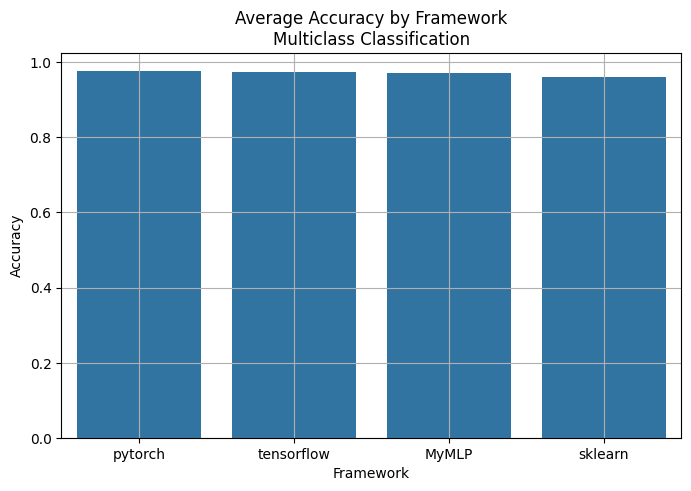

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

mc_framework_mean = (
    multiclass_results_df
    .groupby("framework")
    ["accuracy"]
    .mean()
    .sort_values(ascending=False)
)


plt.figure(figsize=(8, 5))

sns.barplot(
    x=mc_framework_mean.index,
    y=mc_framework_mean.values
)

plt.title(
    "Average Accuracy by Framework\nMulticlass Classification"
)

plt.ylabel("Accuracy")

plt.xlabel("Framework")

plt.grid(True)

plt.show()

Видим, что кастомная реализация не усткупает библиотечным

График скорости обучения

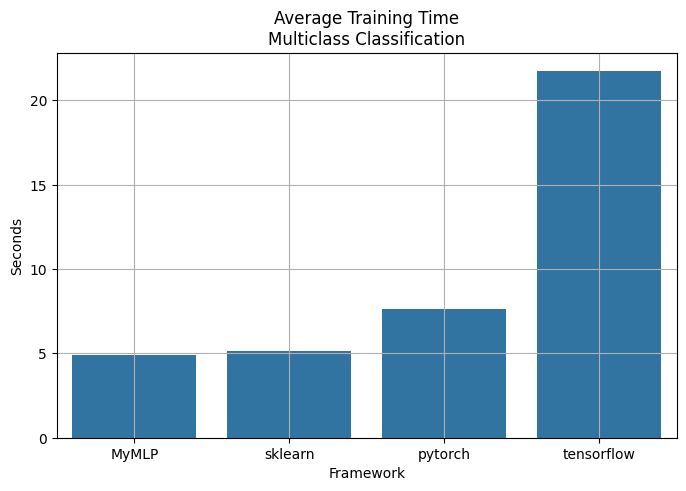

In [ ]:
mc_time = (
    multiclass_results_df
    .groupby("framework")
    ["train_time_sec"]
    .mean()
    .sort_values()
)


plt.figure(figsize=(8, 5))

sns.barplot(
    x=mc_time.index,
    y=mc_time.values
)

plt.title(
    "Average Training Time\nMulticlass Classification"
)

plt.ylabel("Seconds")

plt.xlabel("Framework")

plt.grid(True)

plt.show()

Кастомная реализация, в силу легковесности, обгоняет библиотечные. Тензор флоу отстает, скорее всего в силу того, что он оптимизирован больше под gpu

График скорости предикта

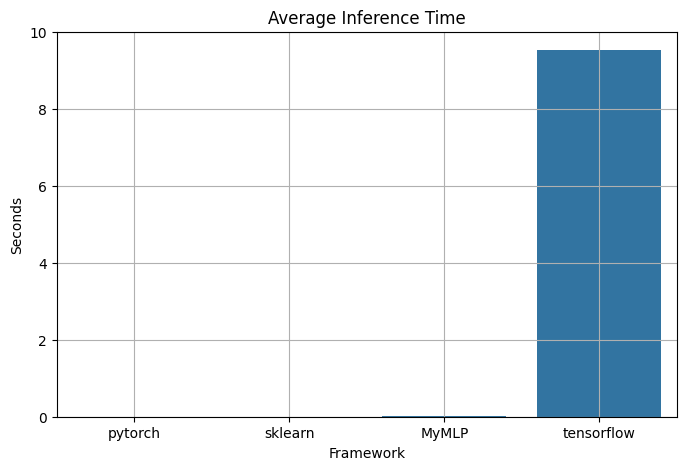

In [ ]:
infer_time = (
    multiclass_results_df
    .groupby("framework")
    ["inference_time_sec"]
    .mean()
    .sort_values()
)


plt.figure(figsize=(8, 5))

sns.barplot(
    x=infer_time.index,
    y=infer_time.values
)

plt.title(
    "Average Inference Time"
)

plt.ylabel("Seconds")

plt.xlabel("Framework")

plt.grid(True)

plt.show()

Аналогично ситуации с обучением -- кастомная реализация показывает себя достойно

Сравнение графиков лоссов на примере

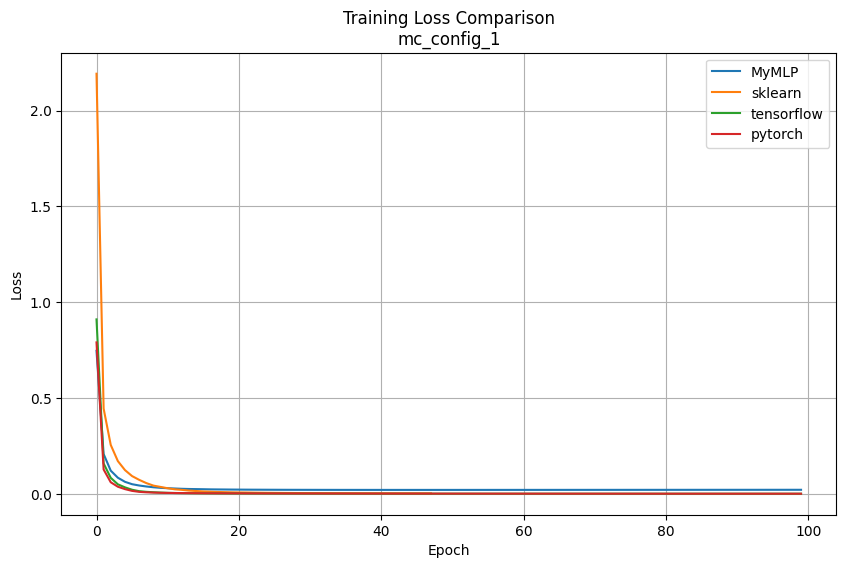

In [ ]:
plt.figure(figsize=(10, 6))

config_name = "mc_config_1"

for framework in (
    multiclass_results_df["framework"]
    .unique()
):

    row = multiclass_results_df[
        (
            multiclass_results_df[
                "framework"
            ] == framework
        )
        &
        (
            multiclass_results_df[
                "config_name"
            ] == config_name
        )
    ].iloc[0]

    if (
        "train_loss_history"
        in row
    ):

        history = row[
            "train_loss_history"
        ]

    elif (
        "loss_history"
        in row
    ):

        history = row[
            "loss_history"
        ]

    else:

        continue


    plt.plot(
        history,
        label=framework
    )


plt.title(
    f"Training Loss Comparison\n{config_name}"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

Видим, что все лоссы очень похожи

Распеределения точночтей по конфигам

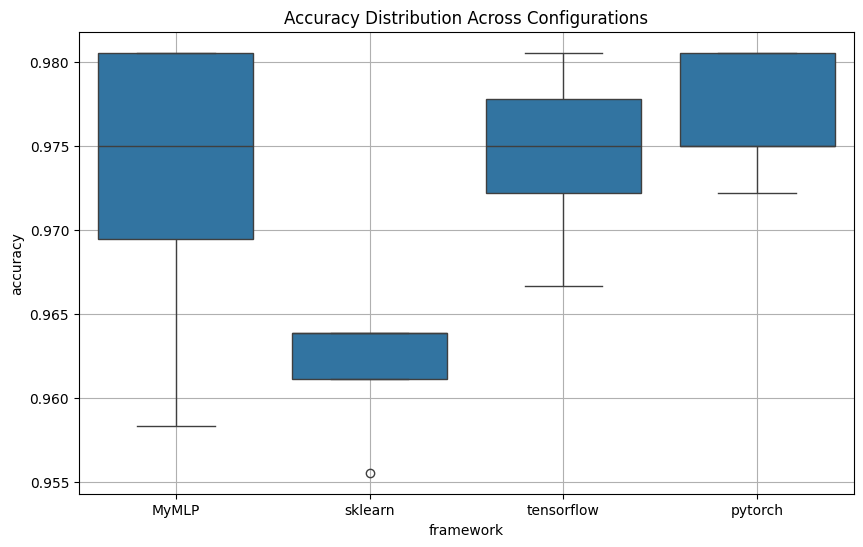

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(

    data=multiclass_results_df,

    x="framework",

    y="accuracy"
)

plt.title(
    "Accuracy Distribution Across Configurations"
)

plt.grid(True)

plt.show()

Все точности примерно одинаковы

## Сравнение фреймворков на задаче бинарной классификации

Сравнивать будем на датасете breast_cancer

Загружаем датасет и подготавливаем данные:

In [ ]:
from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split
)


cancer = load_breast_cancer()

X_binary = cancer.data

y_binary = cancer.target

scaler_binary = StandardScaler()

X_binary = scaler_binary.fit_transform(
    X_binary
)

X_train_binary, X_test_binary, \
y_train_binary, y_test_binary = train_test_split(

    X_binary,

    y_binary,

    test_size=0.2,

    random_state=42,

    stratify=y_binary
)

Конфиги для бинарной классификации

In [ ]:
binary_configs = [

    {
        "name": "binary_config_1",

        "task_type":
            "binary_classification",

        "layer_sizes":
            [30, 32, 1],

        "activations":
            ["relu", "sigmoid"],

        "loss":
            "binary_cross_entropy",

        "learning_rate":
            0.01,

        "batch_size":
            32
    },


    {
        "name": "binary_config_2",

        "task_type":
            "binary_classification",

        "layer_sizes":
            [30, 64, 32, 1],

        "activations":
            ["relu", "relu", "sigmoid"],

        "loss":
            "binary_cross_entropy",

        "learning_rate":
            0.001,

        "batch_size":
            32
    },


    {
        "name": "binary_config_3",

        "task_type":
            "binary_classification",

        "layer_sizes":
            [30, 128, 64, 1],

        "activations":
            ["relu", "relu", "sigmoid"],

        "loss":
            "binary_cross_entropy",

        "learning_rate":
            0.0005,

        "batch_size":
            64
    },


    {
        "name": "binary_config_4",

        "task_type":
            "binary_classification",

        "layer_sizes":
            [30, 16, 1],

        "activations":
            ["sigmoid", "sigmoid"],

        "loss":
            "binary_cross_entropy",

        "learning_rate":
            0.005,

        "batch_size":
            16
    },


    {
        "name": "binary_config_5",

        "task_type":
            "binary_classification",

        "layer_sizes":
            [30, 64, 64, 32, 1],

        "activations":
            ["relu", "relu", "relu", "sigmoid"],

        "loss":
            "binary_cross_entropy",

        "learning_rate":
            0.0001,

        "batch_size":
            128
    }
]

### Обучение и предикт с помощью MyMLP

In [ ]:
binary_mymlp_results = []


y_train_binary_nn = y_train_binary.reshape(
    -1,
    1
)

y_test_binary_nn = y_test_binary.reshape(
    -1,
    1
)


# обучение и предикт для каждого конфига
for config in binary_configs:

    print("=" * 50)
    print(config["name"])
    print("=" * 50)


    layer_sizes = config["layer_sizes"]

    activations = config["activations"]

    learning_rate = config["learning_rate"]

    batch_size = config["batch_size"]

    loss = config["loss"]



    model = MyMLP(

        layer_sizes=layer_sizes,

        activations=activations,

        loss=loss,

        learning_rate=learning_rate,

        epochs=100,

        batch_size=batch_size,

        regularization="l2",

        lambda_=0.0001,

        weight_init="he",

        early_stopping=True,

        patience=10,

        gradient_clip=5,

        random_state=42
    )



    start_train = time.time()

    model.fit(

        X_train_binary,

        y_train_binary_nn,

        X_val=X_test_binary,

        y_val=y_test_binary_nn,

        verbose=False
    )

    end_train = time.time()

    training_time = (
        end_train - start_train
    )

    start_infer = time.time()

    y_pred = model.predict(
        X_test_binary
    )

    end_infer = time.time()

    inference_time = (
        end_infer - start_infer
    )

    metrics = model.evaluate(
        X_test_binary,
        y_test_binary_nn
    )

    binary_mymlp_results.append({

        "framework": "MyMLP",

        "config_name": config["name"],

        "task_type":
            "binary_classification",

        "layer_sizes": layer_sizes,

        "activations": activations,

        "learning_rate": learning_rate,

        "batch_size": batch_size,

        "train_time_sec":
            training_time,

        "inference_time_sec":
            inference_time,

        "accuracy":
            metrics.get(
                "Accuracy",
                None
            ),

        "f1":
            metrics.get(
                "F1",
                None
            ),

        "train_loss_history":
            model.train_loss_history,

        "val_loss_history":
            model.val_loss_history,

        "model": model
    })

binary_mymlp_results_df = pd.DataFrame(
    binary_mymlp_results
)


binary_mymlp_results_df

binary_config_1
binary_config_2
binary_config_3
binary_config_4
binary_config_5


,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,accuracy,f1,train_loss_history,val_loss_history,model
0,MyMLP,binary_config_1,binary_classification,"[30, 32, 1]","[relu, sigmoid]",0.0100,32,0.278139,0.000072,0.956140,0.964539,"[0.28002619153456143, 0.1239773217893456, 0.09...","[0.14565523557106488, 0.11975716435954126, 0.1...",<__main__.MyMLP object at 0x7c7e624d9dc0>
1,MyMLP,binary_config_2,binary_classification,"[30, 64, 32, 1]","[relu, relu, sigmoid]",0.0010,32,0.419796,0.000102,0.947368,0.957746,"[0.4071271239639844, 0.2544649503667019, 0.192...","[0.27843784367687885, 0.22453175080185836, 0.1...",<__main__.MyMLP object at 0x7c7e8246a660>
2,MyMLP,binary_config_3,binary_classification,"[30, 128, 64, 1]","[relu, relu, sigmoid]",0.0005,64,0.983434,0.000261,0.964912,0.972222,"[0.8563552388874216, 0.38525136393269754, 0.29...","[0.4465642436768458, 0.3180580846734889, 0.269...",<__main__.MyMLP object at 0x7c7e82175d30>
3,MyMLP,binary_config_4,binary_classification,"[30, 16, 1]","[sigmoid, sigmoid]",0.0050,16,0.517897,0.000064,0.956140,0.964539,"[0.47009604224366713, 0.32255761685637585, 0.2...","[0.3740099842098894, 0.2874912225912519, 0.238...",<__main__.MyMLP object at 0x7c7e62681be0>
4,MyMLP,binary_config_5,binary_classification,"[30, 64, 64, 32, 1]","[relu, relu, relu, sigmoid]",0.0001,128,0.585141,0.000255,0.956140,0.965035,"[1.1971604565171412, 1.0422753875420772, 0.906...","[0.9604454682622419, 0.8386653041954856, 0.745...",<__main__.MyMLP object at 0x7c7e62680bc0>


### Обучение и предикт с помощью sklearn MLPClassifier

In [ ]:
from sklearn.neural_network import (
    MLPClassifier
)

binary_sklearn_results = []

activation_mapping = {

    "relu": "relu",

    "sigmoid": "logistic",

    "linear": "identity"
}

# создание модели, обучение и предикт по конфигу
for config in binary_configs:

    print("=" * 50)
    print(config["name"])
    print("=" * 50)


    layer_sizes = config["layer_sizes"]

    activations = config["activations"]

    learning_rate = config["learning_rate"]

    batch_size = config["batch_size"]

    hidden_layers = tuple(
        layer_sizes[1:-1]
    )

    hidden_activation = (
        activation_mapping[
            activations[0]
        ]
    )


    model = MLPClassifier(

        hidden_layer_sizes=hidden_layers,

        activation=hidden_activation,

        learning_rate_init=learning_rate,

        batch_size=batch_size,

        max_iter=100,

        random_state=42
    )

    start_train = time.time()

    model.fit(
        X_train_binary,
        y_train_binary
    )

    end_train = time.time()

    training_time = (
        end_train - start_train
    )


    start_infer = time.time()

    y_pred = model.predict(
        X_test_binary
    )

    end_infer = time.time()

    inference_time = (
        end_infer - start_infer
    )


    accuracy = accuracy_score(
        y_test_binary,
        y_pred
    )

    f1 = f1_score(
        y_test_binary,
        y_pred
    )

    binary_sklearn_results.append({

        "framework": "sklearn",

        "config_name": config["name"],

        "task_type":
            "binary_classification",

        "layer_sizes":
            layer_sizes,

        "activations":
            activations,

        "learning_rate":
            learning_rate,

        "batch_size":
            batch_size,

        "train_time_sec":
            training_time,

        "inference_time_sec":
            inference_time,

        "accuracy":
            accuracy,

        "f1":
            f1,

        "train_loss_history":
            model.loss_curve_,

        "model":
            model
    })


binary_sklearn_results_df = pd.DataFrame(
    binary_sklearn_results
)

binary_sklearn_results_df

binary_config_1
binary_config_2
binary_config_3


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


binary_config_4


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


binary_config_5


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,accuracy,f1,train_loss_history,model
0,sklearn,binary_config_1,binary_classification,"[30, 32, 1]","[relu, sigmoid]",0.0100,32,0.966139,0.001915,0.956140,0.964539,"[0.28165951048263727, 0.0771927760953013, 0.06...","MLPClassifier(batch_size=32, hidden_layer_size..."
1,sklearn,binary_config_2,binary_classification,"[30, 64, 32, 1]","[relu, relu, sigmoid]",0.0010,32,2.353333,0.002934,0.964912,0.971831,"[0.5308531423740647, 0.28235866832322715, 0.18...","MLPClassifier(batch_size=32, hidden_layer_size..."
2,sklearn,binary_config_3,binary_classification,"[30, 128, 64, 1]","[relu, relu, sigmoid]",0.0005,64,7.496464,0.009081,0.964912,0.971831,"[0.6244920629708066, 0.41275064942969325, 0.29...","MLPClassifier(batch_size=64, hidden_layer_size..."
3,sklearn,binary_config_4,binary_classification,"[30, 16, 1]","[sigmoid, sigmoid]",0.0050,16,4.331115,0.002158,0.964912,0.971831,"[0.4589373945065492, 0.2598733328890717, 0.169...","MLPClassifier(activation='logistic', batch_siz..."
4,sklearn,binary_config_5,binary_classification,"[30, 64, 64, 32, 1]","[relu, relu, relu, sigmoid]",0.0001,128,1.486077,0.000750,0.956140,0.965035,"[0.6516956482625818, 0.6409639111188878, 0.630...","MLPClassifier(batch_size=128, hidden_layer_siz..."


### Обучение и предикт с помощью tensorflow

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

binary_tensorflow_results = []

y_train_binary_tf = y_train_binary.reshape(
    -1,
    1
)

y_test_binary_tf = y_test_binary.reshape(
    -1,
    1
)


# создание модели, обучение и предикт по конфигу
for config in binary_configs:

    print("=" * 50)
    print(config["name"])
    print("=" * 50)

    layer_sizes = config["layer_sizes"]

    activations = config["activations"]

    learning_rate = config["learning_rate"]

    batch_size = config["batch_size"]

    model = Sequential()

    hidden_layers = layer_sizes[1:-1]

    hidden_activations = activations[:-1]


    for i, (neurons, activation) in enumerate(
        zip(
            hidden_layers,
            hidden_activations
        )
    ):

        if i == 0:

            model.add(
                Dense(
                    neurons,

                    activation=activation,

                    input_shape=(
                        X_train_binary.shape[1],
                    )
                )
            )


        else:

            model.add(
                Dense(
                    neurons,

                    activation=activation
                )
            )


    output_neurons = layer_sizes[-1]

    output_activation = activations[-1]


    model.add(
        Dense(
            output_neurons,

            activation=output_activation
        )
    )


    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    start_train = time.time()

    history = model.fit(

        X_train_binary,

        y_train_binary_tf,

        epochs=100,

        batch_size=batch_size,

        validation_split=0.2,

        verbose=0
    )

    end_train = time.time()

    training_time = (
        end_train - start_train
    )


    start_infer = time.time()

    y_pred_probs = model.predict(
        X_test_binary,
        verbose=0
    )

    y_pred = (
        y_pred_probs > 0.5
    ).astype(int).flatten()

    end_infer = time.time()

    inference_time = (
        end_infer - start_infer
    )


    accuracy = accuracy_score(
        y_test_binary,
        y_pred
    )

    f1 = f1_score(
        y_test_binary,
        y_pred
    )


    binary_tensorflow_results.append({

        "framework": "tensorflow",

        "config_name": config["name"],

        "task_type":
            "binary_classification",

        "layer_sizes":
            layer_sizes,

        "activations":
            activations,

        "learning_rate":
            learning_rate,

        "batch_size":
            batch_size,

        "train_time_sec":
            training_time,

        "inference_time_sec":
            inference_time,

        "accuracy":
            accuracy,

        "f1":
            f1,

        "train_loss_history":
            history.history["loss"],

        "val_loss_history":
            history.history["val_loss"],

        "model":
            model
    })

binary_tensorflow_results_df = pd.DataFrame(
    binary_tensorflow_results
)

binary_tensorflow_results_df

binary_config_1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


binary_config_2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


binary_config_3


...

binary_config_4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


binary_config_5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,accuracy,f1,train_loss_history,val_loss_history,model
0,tensorflow,binary_config_1,binary_classification,"[30, 32, 1]","[relu, sigmoid]",0.0100,32,15.434646,0.129087,0.964912,0.971831,"[0.2522994875907898, 0.09012360870838165, 0.06...","[0.10260888189077377, 0.05450092628598213, 0.0...","<Sequential name=sequential_37, built=True>"
1,tensorflow,binary_config_2,binary_classification,"[30, 64, 32, 1]","[relu, relu, sigmoid]",0.0010,32,22.775532,0.394412,0.956140,0.964539,"[0.5555187463760376, 0.32165178656578064, 0.21...","[0.40286242961883545, 0.26106128096580505, 0.1...","<Sequential name=sequential_38, built=True>"
2,tensorflow,binary_config_3,binary_classification,"[30, 128, 64, 1]","[relu, relu, sigmoid]",0.0005,64,16.190145,0.742293,0.947368,0.957143,"[0.6422696113586426, 0.4466862082481384, 0.331...","[0.5057772397994995, 0.37655431032180786, 0.29...","<Sequential name=sequential_39, built=True>"
3,tensorflow,binary_config_4,binary_classification,"[30, 16, 1]","[sigmoid, sigmoid]",0.0050,16,33.055969,0.491939,0.947368,0.957143,"[0.5250782370567322, 0.3107476234436035, 0.215...","[0.3875398337841034, 0.25586989521980286, 0.17...","<Sequential name=sequential_40, built=True>"
4,tensorflow,binary_config_5,binary_classification,"[30, 64, 64, 32, 1]","[relu, relu, relu, sigmoid]",0.0001,128,12.602298,0.157982,0.947368,0.958333,"[0.7825535535812378, 0.7676136493682861, 0.753...","[0.7878727316856384, 0.774188756942749, 0.7608...","<Sequential name=sequential_41, built=True>"


### Обучение и предикт с помощью PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


binary_pytorch_results = []

y_train_binary_torch = (
    y_train_binary
    .reshape(-1, 1)
    .astype(np.float32)
)

y_test_binary_torch = (
    y_test_binary
    .reshape(-1, 1)
    .astype(np.float32)
)

X_train_tensor = torch.FloatTensor(
    X_train_binary
).to(device)

X_test_tensor = torch.FloatTensor(
    X_test_binary
).to(device)

y_train_tensor = torch.FloatTensor(
    y_train_binary_torch
).to(device)

y_test_tensor = torch.FloatTensor(
    y_test_binary_torch
).to(device)


# в силу особенности библиотеки было прощзе написать свой класс для создания моделей по конфигу
class BinaryTorchMLP(nn.Module):

    def __init__(
        self,
        layer_sizes,
        activations
    ):

        super().__init__()

        layers = []

        for i in range(
            len(layer_sizes) - 2
        ):

            input_size = layer_sizes[i]

            output_size = layer_sizes[i + 1]

            activation = activations[i]


            # Linear layer
            layers.append(
                nn.Linear(
                    input_size,
                    output_size
                )
            )


            # Activation
            if activation == "relu":

                layers.append(
                    nn.ReLU()
                )

            elif activation == "sigmoid":

                layers.append(
                    nn.Sigmoid()
                )


        layers.append(
            nn.Linear(
                layer_sizes[-2],
                layer_sizes[-1]
            )
        )

        layers.append(
            nn.Sigmoid()
        )


        self.network = nn.Sequential(
            *layers
        )


    def forward(self, x):

        return self.network(x)

# создание модели, обучение и предикт по конфигу
for config in binary_configs:

    print("=" * 50)
    print(config["name"])
    print("=" * 50)

    layer_sizes = config["layer_sizes"]

    activations = config["activations"]

    learning_rate = config["learning_rate"]

    batch_size = config["batch_size"]

    model = BinaryTorchMLP(
        layer_sizes,
        activations
    ).to(device)


    criterion = nn.BCELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    dataset = torch.utils.data.TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )


    train_loss_history = []

    train_accuracy_history = []

    start_train = time.time()


    for epoch in range(100):

        model.train()

        epoch_loss = 0

        correct = 0

        total = 0


        for batch_X, batch_y in dataloader:

            optimizer.zero_grad()

            # Forward
            outputs = model(batch_X)

            # Loss
            loss = criterion(
                outputs,
                batch_y
            )

            # Backward
            loss.backward()

            # Update
            optimizer.step()


            epoch_loss += loss.item()

            # Predictions
            predictions = (
                outputs > 0.5
            ).float()


            correct += (
                predictions == batch_y
            ).sum().item()

            total += batch_y.size(0)


        avg_loss = (
            epoch_loss / len(dataloader)
        )

        accuracy = correct / total


        train_loss_history.append(
            avg_loss
        )

        train_accuracy_history.append(
            accuracy
        )


    end_train = time.time()

    training_time = (
        end_train - start_train
    )


    model.eval()

    start_infer = time.time()

    with torch.no_grad():

        outputs = model(
            X_test_tensor
        )

        y_pred = (
            outputs > 0.5
        ).cpu().numpy().astype(int)


    end_infer = time.time()

    inference_time = (
        end_infer - start_infer
    )


    y_pred = y_pred.flatten()


    accuracy = accuracy_score(
        y_test_binary,
        y_pred
    )

    f1 = f1_score(
        y_test_binary,
        y_pred
    )

    binary_pytorch_results.append({

        "framework": "pytorch",

        "config_name": config["name"],

        "task_type":
            "binary_classification",

        "layer_sizes":
            layer_sizes,

        "activations":
            activations,

        "learning_rate":
            learning_rate,

        "batch_size":
            batch_size,

        "train_time_sec":
            training_time,

        "inference_time_sec":
            inference_time,

        "accuracy":
            accuracy,

        "f1":
            f1,

        "train_loss_history":
            train_loss_history,

        "train_accuracy_history":
            train_accuracy_history,

        "model":
            model
    })


binary_pytorch_results_df = pd.DataFrame(
    binary_pytorch_results
)

binary_pytorch_results_df

binary_config_1
binary_config_2
binary_config_3
binary_config_4
binary_config_5


,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,accuracy,f1,train_loss_history,train_accuracy_history,model
0,pytorch,binary_config_1,binary_classification,"[30, 32, 1]","[relu, sigmoid]",0.0100,32,1.776016,0.000178,0.956140,0.964539,"[0.335540338853995, 0.08490202721829215, 0.062...","[0.865934065934066, 0.9714285714285714, 0.9802...",BinaryTorchMLP(\n (network): Sequential(\n ...
1,pytorch,binary_config_2,binary_classification,"[30, 64, 32, 1]","[relu, relu, sigmoid]",0.0010,32,2.110980,0.000244,0.956140,0.964539,"[0.6440325458844502, 0.5042650282382966, 0.331...","[0.6571428571428571, 0.8945054945054945, 0.934...",BinaryTorchMLP(\n (network): Sequential(\n ...
2,pytorch,binary_config_3,binary_classification,"[30, 128, 64, 1]","[relu, relu, sigmoid]",0.0005,64,1.376811,0.000243,0.956140,0.964539,"[0.6485404223203659, 0.5562389120459557, 0.475...","[0.6461538461538462, 0.843956043956044, 0.9230...",BinaryTorchMLP(\n (network): Sequential(\n ...
3,pytorch,binary_config_4,binary_classification,"[30, 16, 1]","[sigmoid, sigmoid]",0.0050,16,3.000190,0.000177,0.964912,0.971831,"[0.5316836751740555, 0.288742788392922, 0.1714...","[0.7802197802197802, 0.9252747252747253, 0.960...",BinaryTorchMLP(\n (network): Sequential(\n ...
4,pytorch,binary_config_5,binary_classification,"[30, 64, 64, 32, 1]","[relu, relu, relu, sigmoid]",0.0001,128,0.949733,0.000272,0.982456,0.986111,"[0.6957845389842987, 0.6930733174085617, 0.690...","[0.36923076923076925, 0.36923076923076925, 0.3...",BinaryTorchMLP(\n (network): Sequential(\n ...


### Собираем все тесты в один и строим графики

In [ ]:
binary_results_df = pd.concat([binary_mymlp_results_df, binary_sklearn_results_df, binary_tensorflow_results_df, binary_pytorch_results_df])
binary_results_df

,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,accuracy,f1,train_loss_history,val_loss_history,model,train_accuracy_history
0,MyMLP,binary_config_1,binary_classification,"[30, 32, 1]","[relu, sigmoid]",0.0100,32,0.278139,0.000072,0.956140,0.964539,"[0.28002619153456143, 0.1239773217893456, 0.09...","[0.14565523557106488, 0.11975716435954126, 0.1...",<__main__.MyMLP object at 0x7c7e624d9dc0>,NaN
1,MyMLP,binary_config_2,binary_classification,"[30, 64, 32, 1]","[relu, relu, sigmoid]",0.0010,32,0.419796,0.000102,0.947368,0.957746,"[0.4071271239639844, 0.2544649503667019, 0.192...","[0.27843784367687885, 0.22453175080185836, 0.1...",<__main__.MyMLP object at 0x7c7e8246a660>,NaN
2,MyMLP,binary_config_3,binary_classification,"[30, 128, 64, 1]","[relu, relu, sigmoid]",0.0005,64,0.983434,0.000261,0.964912,0.972222,"[0.8563552388874216, 0.38525136393269754, 0.29...","[0.4465642436768458, 0.3180580846734889, 0.269...",<__main__.MyMLP object at 0x7c7e82175d30>,NaN
3,MyMLP,binary_config_4,binary_classification,"[30, 16, 1]","[sigmoid, sigmoid]",0.0050,16,0.517897,0.000064,0.956140,0.964539,"[0.47009604224366713, 0.32255761685637585, 0.2...","[0.3740099842098894, 0.2874912225912519, 0.238...",<__main__.MyMLP object at 0x7c7e62681be0>,NaN
4,MyMLP,binary_config_5,binary_classification,"[30, 64, 64, 32, 1]","[relu, relu, relu, sigmoid]",0.0001,128,0.585141,0.000255,0.956140,0.965035,"[1.1971604565171412, 1.0422753875420772, 0.906...","[0.9604454682622419, 0.8386653041954856, 0.745...",<__main__.MyMLP object at 0x7c7e62680bc0>,NaN
0,sklearn,binary_config_1,binary_classification,"[30, 32, 1]","[relu, sigmoid]",0.0100,32,0.694098,0.000605,0.956140,0.964539,"[0.28165951048263727, 0.0771927760953013, 0.06...",NaN,"MLPClassifier(batch_size=32, hidden_layer_size...",NaN
1,sklearn,binary_config_2,binary_classification,"[30, 64, 32, 1]","[relu, relu, sigmoid]",0.0010,32,1.035515,0.000691,0.964912,0.971831,"[0.5308531423740647, 0.28235866832322715, 0.18...",NaN,"MLPClassifier(batch_size=32, hidden_layer_size...",NaN
2,sklearn,binary_config_3,binary_classification,"[30, 128, 64, 1]","[relu, relu, sigmoid]",0.0005,64,4.148928,0.001879,0.964912,0.971831,"[0.6244920629708066, 0.41275064942969325, 0.29...",NaN,"MLPClassifier(batch_size=64, hidden_layer_size...",NaN
3,sklearn,binary_config_4,binary_classification,"[30, 16, 1]","[sigmoid, sigmoid]",0.0050,16,1.445829,0.002840,0.964912,0.971831,"[0.4589373945065492, 0.2598733328890717, 0.169...",NaN,"MLPClassifier(activation='logistic', batch_siz...",NaN
4,sklearn,binary_config_5,binary_classification,"[30, 64, 64, 32, 1]","[relu, relu, relu, sigmoid]",0.0001,128,1.783846,0.000679,0.956140,0.965035,"[0.6516956482625818, 0.6409639111188878, 0.630...",NaN,"MLPClassifier(batch_size=128, hidden_layer_siz...",NaN


График точности фреймворков

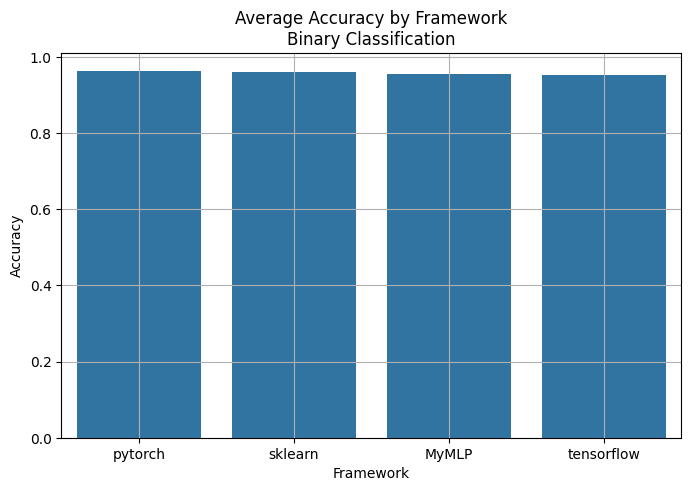

In [ ]:
binary_framework_mean = (
    binary_results_df
    .groupby("framework")
    ["accuracy"]
    .mean()
    .sort_values(ascending=False)
)


plt.figure(figsize=(8, 5))

sns.barplot(
    x=binary_framework_mean.index,
    y=binary_framework_mean.values
)

plt.title(
    "Average Accuracy by Framework\nBinary Classification"
)

plt.ylabel("Accuracy")

plt.xlabel("Framework")

plt.grid(True)

plt.show()

Видим, что все фремворки показали одинаково хорошие результаты

График скорости обучения

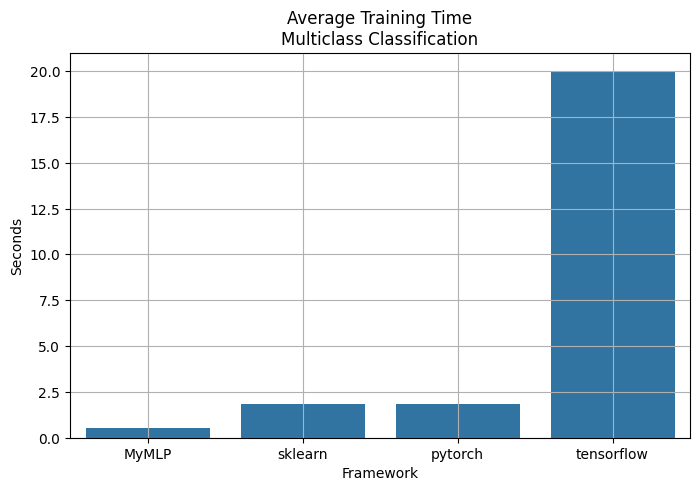

In [ ]:
mc_time = (
    binary_results_df
    .groupby("framework")
    ["train_time_sec"]
    .mean()
    .sort_values()
)


plt.figure(figsize=(8, 5))

sns.barplot(
    x=mc_time.index,
    y=mc_time.values
)

plt.title(
    "Average Training Time\nMulticlass Classification"
)

plt.ylabel("Seconds")

plt.xlabel("Framework")

plt.grid(True)

plt.show()

Такой же результат, что и для мультклассовой классификации: Кастомная реализация, в силу легковесности, обгоняет библиотечные. Тензор флоу отстает, скорее всего в силу того, что он оптимизирован больше под gpu

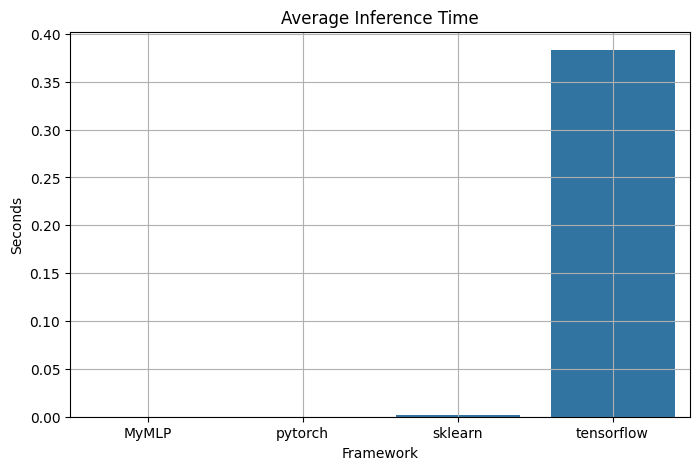

In [ ]:
infer_time = (
    binary_results_df
    .groupby("framework")
    ["inference_time_sec"]
    .mean()
    .sort_values()
)


plt.figure(figsize=(8, 5))

sns.barplot(
    x=infer_time.index,
    y=infer_time.values
)

plt.title(
    "Average Inference Time"
)

plt.ylabel("Seconds")

plt.xlabel("Framework")

plt.grid(True)

plt.show()

Аналогично ситуации с обучением -- кастомная реализация показывает себя достойно

Сравнение графиков лоссов на примере

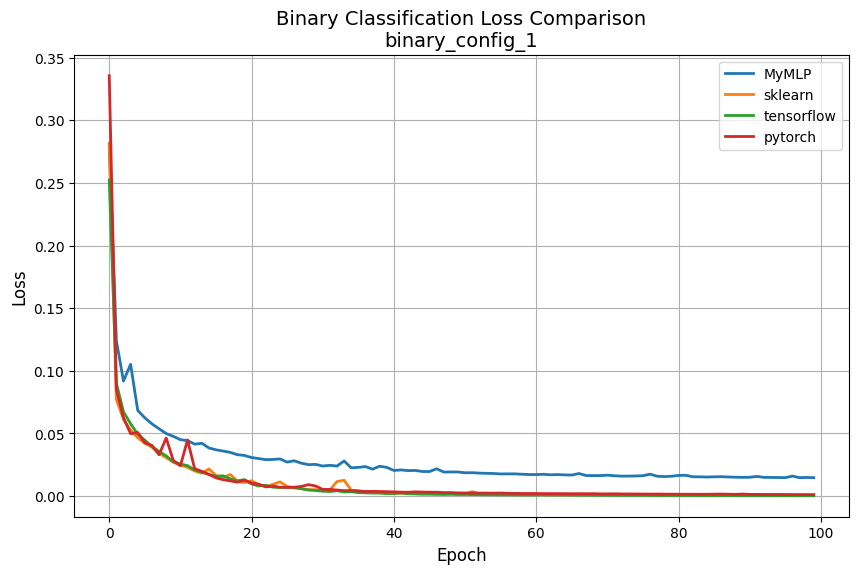

In [ ]:
import matplotlib.pyplot as plt

config_name = "binary_config_1"

plt.figure(figsize=(10, 6))

for framework in (
    binary_results_df["framework"]
    .unique()
):

    row = binary_results_df[
        (
            binary_results_df[
                "framework"
            ] == framework
        )
        &
        (
            binary_results_df[
                "config_name"
            ] == config_name
        )
    ]


    row = row.iloc[0]

    history = None


    if (
        "train_loss_history"
        in row.index
    ):

        history = row[
            "train_loss_history"
        ]


    elif (
        "loss_history"
        in row.index
    ):

        history = row[
            "loss_history"
        ]


    plt.plot(
        history,
        label=framework,
        linewidth=2
    )


plt.title(
    f"Binary Classification Loss Comparison\n{config_name}",
    fontsize=14
)

plt.xlabel(
    "Epoch",
    fontsize=12
)

plt.ylabel(
    "Loss",
    fontsize=12
)

plt.legend()

plt.grid(True)

plt.show()

Видим, что лосс для кастомной реализации немного выше других, но имеет схожую структуру, что некритично

Распеределения точностей по конфигам

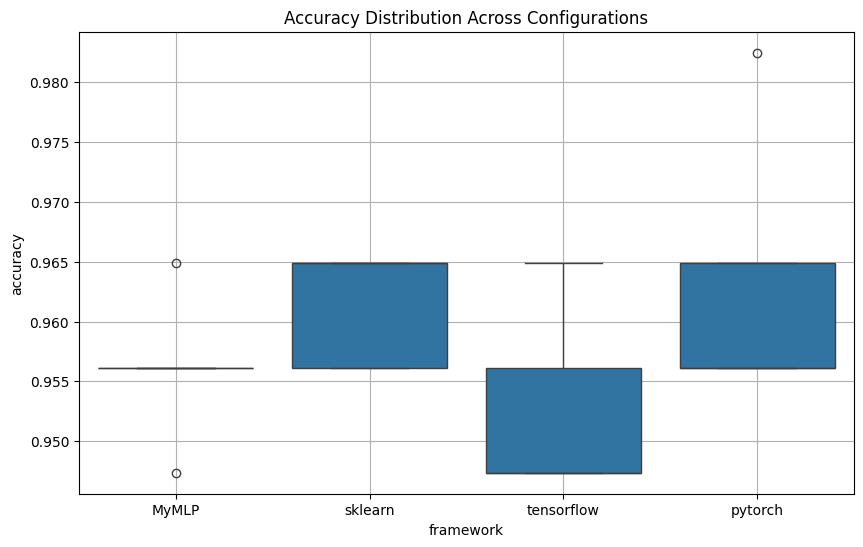

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(

    data=binary_results_df,

    x="framework",

    y="accuracy"
)

plt.title(
    "Accuracy Distribution Across Configurations"
)

plt.grid(True)

plt.show()

## Сравнение для регрессии

Сравнивать будем на датсете fetch_california_housing

Загружаем данные и подготавливаем их

In [ ]:
from sklearn.datasets import (
    fetch_california_housing
)

housing = fetch_california_housing()

X_reg = housing.data

y_reg = housing.target

scaler_reg = StandardScaler()

X_reg = scaler_reg.fit_transform(
    X_reg
)

y_reg = y_reg.reshape(-1, 1)

target_scaler = StandardScaler()

y_reg = target_scaler.fit_transform(
    y_reg
)

X_train_reg, X_test_reg, \
y_train_reg, y_test_reg = train_test_split(

    X_reg,

    y_reg,

    test_size=0.2,

    random_state=42
)

Создаем конфиги для регрессии

In [ ]:
regression_configs = [

    {
        "name": "regression_config_1",

        "task_type":
            "regression",

        "layer_sizes":
            [8, 32, 1],

        "activations":
            ["relu", "linear"],

        "loss":
            "mse",

        "learning_rate":
            0.01,

        "batch_size":
            32
    },


    {
        "name": "regression_config_2",

        "task_type":
            "regression",

        "layer_sizes":
            [8, 64, 32, 1],

        "activations":
            ["relu", "relu", "linear"],

        "loss":
            "mse",

        "learning_rate":
            0.001,

        "batch_size":
            64
    },


    {
        "name": "regression_config_3",

        "task_type":
            "regression",

        "layer_sizes":
            [8, 128, 64, 1],

        "activations":
            ["relu", "relu", "linear"],

        "loss":
            "mse",

        "learning_rate":
            0.0005,

        "batch_size":
            128
    },


    {
        "name": "regression_config_4",

        "task_type":
            "regression",

        "layer_sizes":
            [8, 16, 16, 1],

        "activations":
            ["sigmoid", "sigmoid", "linear"],

        "loss":
            "mse",

        "learning_rate":
            0.005,

        "batch_size":
            32
    },


    {
        "name": "regression_config_5",

        "task_type":
            "regression",

        "layer_sizes":
            [8, 128, 128, 64, 1],

        "activations":
            ["relu", "relu", "relu", "linear"],

        "loss":
            "mse",

        "learning_rate":
            0.0001,

        "batch_size":
            256
    }
]

### Обучение и предикт с помощью MyMLP

In [ ]:
regression_mymlp_results = []

# обучение и предикт для каждого конфига
for config in regression_configs:

    print("=" * 50)
    print(config["name"])
    print("=" * 50)


    layer_sizes = config["layer_sizes"]

    activations = config["activations"]

    learning_rate = config["learning_rate"]

    batch_size = config["batch_size"]

    loss = config["loss"]


    model = MyMLP(

        layer_sizes=layer_sizes,

        activations=activations,

        loss=loss,

        learning_rate=learning_rate,

        epochs=100,

        batch_size=batch_size,

        regularization="l2",

        lambda_=0.0001,

        weight_init="he",

        early_stopping=True,

        patience=10,

        gradient_clip=5,

        random_state=42
    )


    start_train = time.time()

    model.fit(

        X_train_reg,

        y_train_reg,

        X_val=X_test_reg,

        y_val=y_test_reg,

        verbose=False
    )

    end_train = time.time()

    training_time = (
        end_train - start_train
    )

    start_infer = time.time()

    y_pred = model.predict(
        X_test_reg
    )

    end_infer = time.time()

    inference_time = (
        end_infer - start_infer
    )

    y_pred = y_pred.flatten()

    y_true = y_test_reg.flatten()


    from sklearn.metrics import (
        mean_absolute_error,
        mean_squared_error,
        r2_score
    )


    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    regression_mymlp_results.append({

        "framework": "MyMLP",

        "config_name": config["name"],

        "task_type":
            "regression",

        "layer_sizes":
            layer_sizes,

        "activations":
            activations,

        "learning_rate":
            learning_rate,

        "batch_size":
            batch_size,

        "loss":
            loss,

        "train_time_sec":
            training_time,

        "inference_time_sec":
            inference_time,

        "mae":
            mae,

        "mse":
            mse,

        "rmse":
            rmse,

        "r2":
            r2,

        "train_loss_history":
            model.train_loss_history,

        "val_loss_history":
            model.val_loss_history,

        "model":
            model
    })

regression_mymlp_results_df = pd.DataFrame(
    regression_mymlp_results
)

regression_mymlp_results_df

regression_config_1
regression_config_2
regression_config_3
regression_config_4
regression_config_5


,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,loss,train_time_sec,inference_time_sec,mae,mse,rmse,r2,train_loss_history,val_loss_history,model
0,MyMLP,regression_config_1,regression,"[8, 32, 1]","[relu, linear]",0.0100,32,mse,13.796231,0.007849,0.338582,0.248539,0.498537,0.747451,"[0.5606689718550828, 0.4096454078372489, 0.420...","[0.43932979883749185, 0.4332060021007368, 0.39...",<__main__.MyMLP object at 0x7c7e3fab6b40>
1,MyMLP,regression_config_2,regression,"[8, 64, 32, 1]","[relu, relu, linear]",0.0010,64,mse,11.880749,0.007565,0.389113,0.301857,0.549415,0.693273,"[0.8512270751390695, 0.5909445274944426, 0.540...","[0.6368756842117058, 0.568699585990977, 0.5273...",<__main__.MyMLP object at 0x7c7e46121fd0>
2,MyMLP,regression_config_3,regression,"[8, 128, 64, 1]","[relu, relu, linear]",0.0005,128,mse,18.700640,0.012264,0.409919,0.327710,0.572459,0.667003,"[1.3301572957825332, 0.6820981548225333, 0.606...","[0.7991300012659202, 0.7318414066042558, 0.644...",<__main__.MyMLP object at 0x7c7e3fa19c70>
3,MyMLP,regression_config_4,regression,"[8, 16, 16, 1]","[sigmoid, sigmoid, linear]",0.0050,32,mse,16.906979,0.003517,0.387890,0.312533,0.559047,0.682425,"[0.8951755591414031, 0.755881316491104, 0.6190...","[0.8128595536617991, 0.678559934961879, 0.5610...",<__main__.MyMLP object at 0x7c7e4609ddf0>
4,MyMLP,regression_config_5,regression,"[8, 128, 128, 64, 1]","[relu, relu, relu, linear]",0.0001,256,mse,27.214787,0.022000,0.479324,0.427687,0.653978,0.565413,"[3.0063147327455977, 1.7217940855503207, 1.331...","[1.8442123411660514, 1.3762071254970154, 1.161...",<__main__.MyMLP object at 0x7c7e3feb7350>


### Обучение и предикт с помощью sklearn MLPRegressor

In [ ]:
from sklearn.neural_network import (
    MLPRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

regression_sklearn_results = []

activation_mapping = {

    "relu": "relu",

    "sigmoid": "logistic",

    "linear": "identity"
}

y_train_reg_sklearn = (
    y_train_reg.flatten()
)

y_test_reg_sklearn = (
    y_test_reg.flatten()
)

# создание модели, обучение и предикт по конфигу
for config in regression_configs:

    print("=" * 50)
    print(config["name"])
    print("=" * 50)

    layer_sizes = config["layer_sizes"]

    activations = config["activations"]

    learning_rate = config["learning_rate"]

    batch_size = config["batch_size"]

    hidden_layers = tuple(
        layer_sizes[1:-1]
    )

    hidden_activation = (
        activation_mapping[
            activations[0]
        ]
    )

    model = MLPRegressor(

        hidden_layer_sizes=hidden_layers,

        activation=hidden_activation,

        learning_rate_init=learning_rate,

        batch_size=batch_size,

        max_iter=100,

        random_state=42
    )

    start_train = time.time()

    model.fit(
        X_train_reg,
        y_train_reg_sklearn
    )

    end_train = time.time()

    training_time = (
        end_train - start_train
    )


    start_infer = time.time()

    y_pred = model.predict(
        X_test_reg
    )

    end_infer = time.time()

    inference_time = (
        end_infer - start_infer
    )


    mae = mean_absolute_error(
        y_test_reg_sklearn,
        y_pred
    )

    mse = mean_squared_error(
        y_test_reg_sklearn,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test_reg_sklearn,
        y_pred
    )

    regression_sklearn_results.append({

        "framework": "sklearn",

        "config_name": config["name"],

        "task_type":
            "regression",

        "layer_sizes":
            layer_sizes,

        "activations":
            activations,

        "learning_rate":
            learning_rate,

        "batch_size":
            batch_size,

        "train_time_sec":
            training_time,

        "inference_time_sec":
            inference_time,

        "mae":
            mae,

        "mse":
            mse,

        "rmse":
            rmse,

        "r2":
            r2,

        "train_loss_history":
            model.loss_curve_,

        "model":
            model
    })

regression_sklearn_results_df = pd.DataFrame(
    regression_sklearn_results
)

regression_sklearn_results_df

regression_config_1
regression_config_2


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


regression_config_3


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


regression_config_4


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


regression_config_5


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,mae,mse,rmse,r2,train_loss_history,model
0,sklearn,regression_config_1,regression,"[8, 32, 1]","[relu, linear]",0.0100,32,20.241021,0.011445,0.378757,0.275680,0.525052,0.719873,"[0.24996860649347133, 0.14585390534959766, 0.1...","MLPRegressor(batch_size=32, hidden_layer_sizes..."
1,sklearn,regression_config_2,regression,"[8, 64, 32, 1]","[relu, relu, linear]",0.0010,64,14.266235,0.003413,0.304761,0.199696,0.446874,0.797082,"[0.22505495623320598, 0.15759422572913545, 0.1...","MLPRegressor(batch_size=64, hidden_layer_sizes..."
2,sklearn,regression_config_3,regression,"[8, 128, 64, 1]","[relu, relu, linear]",0.0005,128,33.238091,0.008514,0.303223,0.200472,0.447741,0.796294,"[0.2671716644164185, 0.17504525409398297, 0.15...","MLPRegressor(batch_size=128, hidden_layer_size..."
3,sklearn,regression_config_4,regression,"[8, 16, 16, 1]","[sigmoid, sigmoid, linear]",0.0050,32,22.507200,0.017293,0.315354,0.216116,0.464882,0.780398,"[0.21791084264409116, 0.15055822315773365, 0.1...","MLPRegressor(activation='logistic', batch_size..."
4,sklearn,regression_config_5,regression,"[8, 128, 128, 64, 1]","[relu, relu, relu, linear]",0.0001,256,77.560352,0.025753,0.313204,0.210701,0.459022,0.785899,"[0.39139096788262306, 0.24853589845054846, 0.2...","MLPRegressor(batch_size=256, hidden_layer_size..."


### Обучение и предикт с помощью tensorflow

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

regression_tensorflow_results = []

# создание модели, обучение и предикт по конфигу
for config in regression_configs:

    print("=" * 50)
    print(config["name"])
    print("=" * 50)

    layer_sizes = config["layer_sizes"]

    activations = config["activations"]

    learning_rate = config["learning_rate"]

    batch_size = config["batch_size"]

    model = Sequential()

    hidden_layers = layer_sizes[1:-1]

    hidden_activations = activations[:-1]


    for i, (neurons, activation) in enumerate(
        zip(
            hidden_layers,
            hidden_activations
        )
    ):

        if i == 0:

            model.add(
                Dense(
                    neurons,

                    activation=activation,

                    input_shape=(
                        X_train_reg.shape[1],
                    )
                )
            )

        else:

            model.add(
                Dense(
                    neurons,

                    activation=activation
                )
            )


    output_neurons = layer_sizes[-1]

    output_activation = activations[-1]


    model.add(
        Dense(
            output_neurons,

            activation=output_activation
        )
    )

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss="mse",

        metrics=["mae"]
    )


    start_train = time.time()

    history = model.fit(

        X_train_reg,

        y_train_reg,

        epochs=100,

        batch_size=batch_size,

        validation_split=0.2,

        verbose=0
    )

    end_train = time.time()

    training_time = (
        end_train - start_train
    )

    start_infer = time.time()

    y_pred = model.predict(
        X_test_reg,
        verbose=0
    )

    end_infer = time.time()

    inference_time = (
        end_infer - start_infer
    )


    y_pred = y_pred.flatten()

    y_true = y_test_reg.flatten()


    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    regression_tensorflow_results.append({

        "framework": "tensorflow",

        "config_name": config["name"],

        "task_type":
            "regression",

        "layer_sizes":
            layer_sizes,

        "activations":
            activations,

        "learning_rate":
            learning_rate,

        "batch_size":
            batch_size,

        "train_time_sec":
            training_time,

        "inference_time_sec":
            inference_time,

        "mae":
            mae,

        "mse":
            mse,

        "rmse":
            rmse,

        "r2":
            r2,

        "train_loss_history":
            history.history["loss"],

        "val_loss_history":
            history.history["val_loss"],

        "model":
            model
    })

regression_tensorflow_results_df = pd.DataFrame(
    regression_tensorflow_results
)

regression_tensorflow_results_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


regression_config_1
regression_config_2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


regression_config_3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


regression_config_4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


regression_config_5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,mae,mse,rmse,r2,train_loss_history,val_loss_history,model
0,tensorflow,regression_config_1,regression,"[8, 32, 1]","[relu, linear]",0.0100,32,108.034911,0.278118,0.338941,0.262586,0.512431,0.733178,"[0.38235652446746826, 0.28578490018844604, 0.2...","[0.34182360768318176, 0.2997215986251831, 0.30...","<Sequential name=sequential_42, built=True>"
1,tensorflow,regression_config_2,regression,"[8, 64, 32, 1]","[relu, relu, linear]",0.0010,64,60.916737,0.359148,0.307967,0.215427,0.464141,0.781097,"[0.4765784740447998, 0.3417067527770996, 0.292...","[0.359586626291275, 0.34258270263671875, 0.301...","<Sequential name=sequential_43, built=True>"
2,tensorflow,regression_config_3,regression,"[8, 128, 64, 1]","[relu, relu, linear]",0.0005,128,39.522770,0.308315,0.310613,0.207633,0.455668,0.789017,"[0.5302649736404419, 0.3596087694168091, 0.324...","[0.40053266286849976, 0.3543599247932434, 0.34...","<Sequential name=sequential_44, built=True>"
3,tensorflow,regression_config_4,regression,"[8, 16, 16, 1]","[sigmoid, sigmoid, linear]",0.0050,32,108.783620,0.276648,0.312535,0.217093,0.465933,0.779404,"[0.4343869984149933, 0.30467528104782104, 0.28...","[0.3435789942741394, 0.3404940068721771, 0.310...","<Sequential name=sequential_45, built=True>"
4,tensorflow,regression_config_5,regression,"[8, 128, 128, 64, 1]","[relu, relu, relu, linear]",0.0001,256,34.760344,0.475690,0.322914,0.223324,0.472572,0.773073,"[0.8811711668968201, 0.620856523513794, 0.4644...","[0.7527575492858887, 0.5284386277198792, 0.445...","<Sequential name=sequential_46, built=True>"


### Обучение и предикт с помощью PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

regression_pytorch_results = []

X_train_tensor = torch.FloatTensor(
    X_train_reg
).to(device)

X_test_tensor = torch.FloatTensor(
    X_test_reg
).to(device)

y_train_tensor = torch.FloatTensor(
    y_train_reg
).to(device)

y_test_tensor = torch.FloatTensor(
    y_test_reg
).to(device)


# в силу особенности библиотеки было прощзе написать свой класс для создания моделей по конфигу
class RegressionTorchMLP(nn.Module):

    def __init__(
        self,
        layer_sizes,
        activations
    ):

        super().__init__()

        layers = []

        for i in range(
            len(layer_sizes) - 2
        ):

            input_size = layer_sizes[i]

            output_size = layer_sizes[i + 1]

            activation = activations[i]


            layers.append(
                nn.Linear(
                    input_size,
                    output_size
                )
            )


            if activation == "relu":

                layers.append(
                    nn.ReLU()
                )

            elif activation == "sigmoid":

                layers.append(
                    nn.Sigmoid()
                )


        layers.append(
            nn.Linear(
                layer_sizes[-2],
                layer_sizes[-1]
            )
        )

        self.network = nn.Sequential(
            *layers
        )


    def forward(self, x):

        return self.network(x)


# создание модели, обучение и предикт по конфигу
for config in regression_configs:

    print("=" * 50)
    print(config["name"])
    print("=" * 50)

    layer_sizes = config["layer_sizes"]

    activations = config["activations"]

    learning_rate = config["learning_rate"]

    batch_size = config["batch_size"]


    model = RegressionTorchMLP(
        layer_sizes,
        activations
    ).to(device)


    criterion = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    dataset = torch.utils.data.TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )


    train_loss_history = []

    train_mae_history = []

    start_train = time.time()


    for epoch in range(100):

        model.train()

        epoch_loss = 0

        epoch_mae = 0


        for batch_X, batch_y in dataloader:

            optimizer.zero_grad()


            # Forward
            outputs = model(batch_X)


            # Loss
            loss = criterion(
                outputs,
                batch_y
            )


            # Backward
            loss.backward()


            # Update
            optimizer.step()


            epoch_loss += loss.item()


            mae = torch.mean(
                torch.abs(
                    outputs - batch_y
                )
            )

            epoch_mae += mae.item()


        avg_loss = (
            epoch_loss / len(dataloader)
        )

        avg_mae = (
            epoch_mae / len(dataloader)
        )


        train_loss_history.append(
            avg_loss
        )

        train_mae_history.append(
            avg_mae
        )


    end_train = time.time()

    training_time = (
        end_train - start_train
    )

    model.eval()

    start_infer = time.time()

    with torch.no_grad():

        y_pred = model(
            X_test_tensor
        ).cpu().numpy()


    end_infer = time.time()

    inference_time = (
        end_infer - start_infer
    )

    y_pred = y_pred.flatten()

    y_true = y_test_reg.flatten()

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    regression_pytorch_results.append({

        "framework": "pytorch",

        "config_name": config["name"],

        "task_type":
            "regression",

        "layer_sizes":
            layer_sizes,

        "activations":
            activations,

        "learning_rate":
            learning_rate,

        "batch_size":
            batch_size,

        "train_time_sec":
            training_time,

        "inference_time_sec":
            inference_time,

        "mae":
            mae,

        "mse":
            mse,

        "rmse":
            rmse,

        "r2":
            r2,

        "train_loss_history":
            train_loss_history,

        "model":
            model
    })


regression_pytorch_results_df = pd.DataFrame(
    regression_pytorch_results
)

regression_pytorch_results_df

regression_config_1
regression_config_2
regression_config_3
regression_config_4
regression_config_5


,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,train_time_sec,inference_time_sec,mae,mse,rmse,r2,train_loss_history,model
0,pytorch,regression_config_1,regression,"[8, 32, 1]","[relu, linear]",0.0100,32,61.844852,0.000835,0.359213,0.251559,0.501557,0.744382,"[0.38876129206010074, 0.3122381539509971, 0.29...",RegressionTorchMLP(\n (network): Sequential(\...
1,pytorch,regression_config_2,regression,"[8, 64, 32, 1]","[relu, relu, linear]",0.0010,64,44.882008,0.001796,0.297014,0.197094,0.443953,0.799726,"[0.4739875468288281, 0.3214473000677057, 0.317...",RegressionTorchMLP(\n (network): Sequential(\...
2,pytorch,regression_config_3,regression,"[8, 128, 64, 1]","[relu, relu, linear]",0.0005,128,30.564979,0.003642,0.307871,0.202291,0.449767,0.794446,"[0.5774004874072334, 0.36422185703765514, 0.32...",RegressionTorchMLP(\n (network): Sequential(\...
3,pytorch,regression_config_4,regression,"[8, 16, 16, 1]","[sigmoid, sigmoid, linear]",0.0050,32,73.783095,0.000657,0.308640,0.208200,0.456290,0.788441,"[0.4589853659416585, 0.2985575189886167, 0.290...",RegressionTorchMLP(\n (network): Sequential(\...
4,pytorch,regression_config_5,regression,"[8, 128, 128, 64, 1]","[relu, relu, relu, linear]",0.0001,256,31.718771,0.005687,0.318311,0.213977,0.462576,0.782571,"[0.9301108928827139, 0.636046434365786, 0.4441...",RegressionTorchMLP(\n (network): Sequential(\...


### Собираем все тесты в один и строим графики

In [ ]:
regression_results_df = pd.concat([regression_mymlp_results_df, regression_sklearn_results_df, regression_tensorflow_results_df, regression_pytorch_results_df])

regression_results_df

,framework,config_name,task_type,layer_sizes,activations,learning_rate,batch_size,loss,train_time_sec,inference_time_sec,mae,mse,rmse,r2,train_loss_history,val_loss_history,model
0,MyMLP,regression_config_1,regression,"[8, 32, 1]","[relu, linear]",0.0100,32,mse,13.796231,0.007849,0.338582,0.248539,0.498537,0.747451,"[0.5606689718550828, 0.4096454078372489, 0.420...","[0.43932979883749185, 0.4332060021007368, 0.39...",<__main__.MyMLP object at 0x7c7e3fab6b40>
1,MyMLP,regression_config_2,regression,"[8, 64, 32, 1]","[relu, relu, linear]",0.0010,64,mse,11.880749,0.007565,0.389113,0.301857,0.549415,0.693273,"[0.8512270751390695, 0.5909445274944426, 0.540...","[0.6368756842117058, 0.568699585990977, 0.5273...",<__main__.MyMLP object at 0x7c7e46121fd0>
2,MyMLP,regression_config_3,regression,"[8, 128, 64, 1]","[relu, relu, linear]",0.0005,128,mse,18.700640,0.012264,0.409919,0.327710,0.572459,0.667003,"[1.3301572957825332, 0.6820981548225333, 0.606...","[0.7991300012659202, 0.7318414066042558, 0.644...",<__main__.MyMLP object at 0x7c7e3fa19c70>
3,MyMLP,regression_config_4,regression,"[8, 16, 16, 1]","[sigmoid, sigmoid, linear]",0.0050,32,mse,16.906979,0.003517,0.387890,0.312533,0.559047,0.682425,"[0.8951755591414031, 0.755881316491104, 0.6190...","[0.8128595536617991, 0.678559934961879, 0.5610...",<__main__.MyMLP object at 0x7c7e4609ddf0>
4,MyMLP,regression_config_5,regression,"[8, 128, 128, 64, 1]","[relu, relu, relu, linear]",0.0001,256,mse,27.214787,0.022000,0.479324,0.427687,0.653978,0.565413,"[3.0063147327455977, 1.7217940855503207, 1.331...","[1.8442123411660514, 1.3762071254970154, 1.161...",<__main__.MyMLP object at 0x7c7e3feb7350>
0,sklearn,regression_config_1,regression,"[8, 32, 1]","[relu, linear]",0.0100,32,NaN,20.241021,0.011445,0.378757,0.275680,0.525052,0.719873,"[0.24996860649347133, 0.14585390534959766, 0.1...",NaN,"MLPRegressor(batch_size=32, hidden_layer_sizes..."
1,sklearn,regression_config_2,regression,"[8, 64, 32, 1]","[relu, relu, linear]",0.0010,64,NaN,14.266235,0.003413,0.304761,0.199696,0.446874,0.797082,"[0.22505495623320598, 0.15759422572913545, 0.1...",NaN,"MLPRegressor(batch_size=64, hidden_layer_sizes..."
2,sklearn,regression_config_3,regression,"[8, 128, 64, 1]","[relu, relu, linear]",0.0005,128,NaN,33.238091,0.008514,0.303223,0.200472,0.447741,0.796294,"[0.2671716644164185, 0.17504525409398297, 0.15...",NaN,"MLPRegressor(batch_size=128, hidden_layer_size..."
3,sklearn,regression_config_4,regression,"[8, 16, 16, 1]","[sigmoid, sigmoid, linear]",0.0050,32,NaN,22.507200,0.017293,0.315354,0.216116,0.464882,0.780398,"[0.21791084264409116, 0.15055822315773365, 0.1...",NaN,"MLPRegressor(activation='logistic', batch_size..."
4,sklearn,regression_config_5,regression,"[8, 128, 128, 64, 1]","[relu, relu, relu, linear]",0.0001,256,NaN,77.560352,0.025753,0.313204,0.210701,0.459022,0.785899,"[0.39139096788262306, 0.24853589845054846, 0.2...",NaN,"MLPRegressor(batch_size=256, hidden_layer_size..."


График точности фреймворков

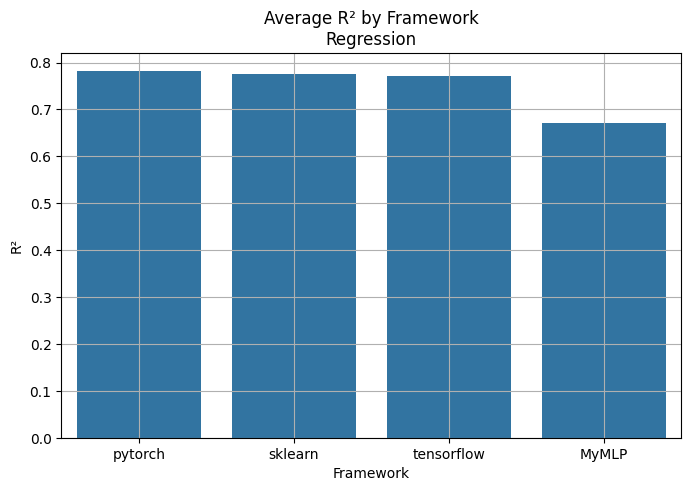

In [ ]:
reg_framework_mean = (
    regression_results_df
    .groupby("framework")
    ["r2"]
    .mean()
    .sort_values(ascending=False)
)


plt.figure(figsize=(8, 5))

sns.barplot(
    x=reg_framework_mean.index,
    y=reg_framework_mean.values
)

plt.title(
    "Average R² by Framework\nRegression"
)

plt.ylabel("R²")

plt.xlabel("Framework")

plt.grid(True)

plt.show()

Видим, что кастомный класс отсает на порятка 0.05 для r2. Это может быть связано с простой реализацией sgd, из-за чего модель не успевает спускаться в минимум при обучении, что особенно сильно сказывается на регрессии, т.к. в классификациях в оценке точности мы апроксимируем значение вероятни на класс, а в регрессии работаем с чистым предиктом, из-за чего копится ошибка

График скорости обучения

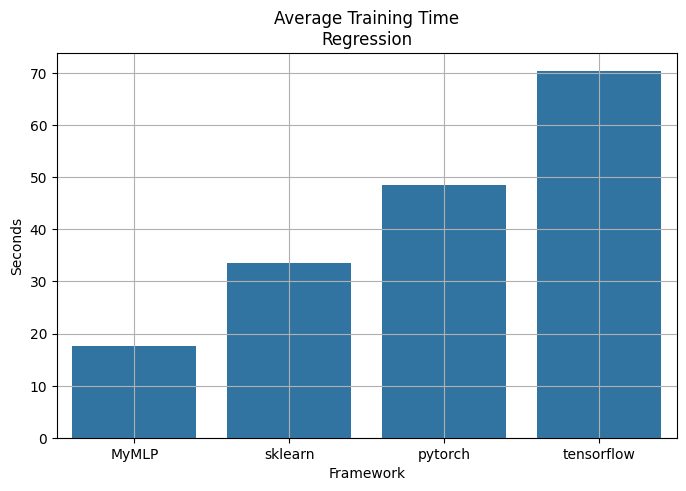

In [ ]:
reg_time = (
    regression_results_df
    .groupby("framework")
    ["train_time_sec"]
    .mean()
    .sort_values()
)


plt.figure(figsize=(8, 5))

sns.barplot(
    x=reg_time.index,
    y=reg_time.values
)

plt.title(
    "Average Training Time\nRegression"
)

plt.ylabel("Seconds")

plt.xlabel("Framework")

plt.grid(True)

plt.show()

Такой же результат, что и для прощлых задач: Кастомная реализация, в силу легковесности, обгоняет библиотечные. Тензор флоу отстает, скорее всего в силу того, что он оптимизирован больше под gpu

Сравнение графиков лоссов на примере

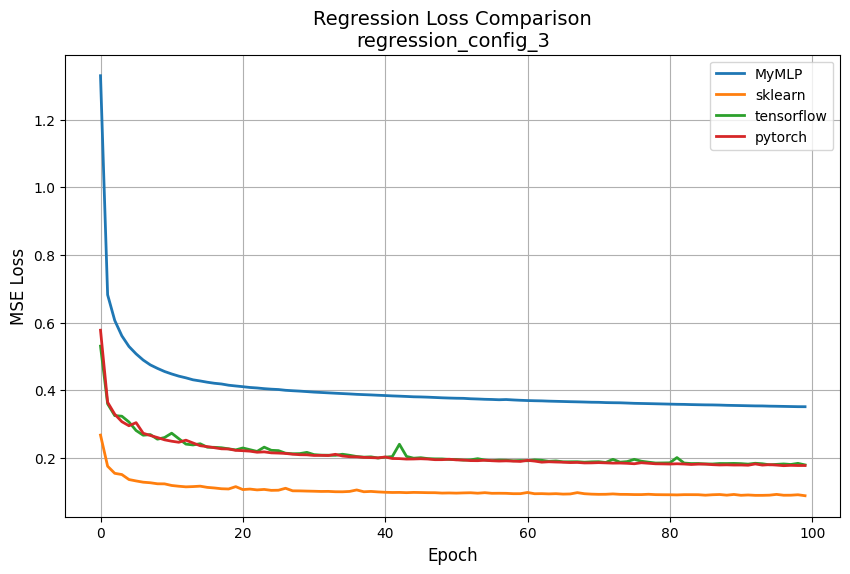

In [ ]:
import matplotlib.pyplot as plt
config_name = "regression_config_3"

plt.figure(figsize=(10, 6))

for framework in (
    regression_results_df["framework"]
    .unique()
):


    row = regression_results_df[
        (
            regression_results_df[
                "framework"
            ] == framework
        )
        &
        (
            regression_results_df[
                "config_name"
            ] == config_name
        )
    ]


    if len(row) == 0:

        continue


    row = row.iloc[0]


    history = None


    if (
        "train_loss_history"
        in row.index
    ):

        history = row[
            "train_loss_history"
        ]


    elif (
        "loss_history"
        in row.index
    ):

        history = row[
            "loss_history"
        ]




    plt.plot(
        history,
        label=framework,
        linewidth=2
    )



plt.title(
    f"Regression Loss Comparison\n{config_name}",
    fontsize=14
)

plt.xlabel(
    "Epoch",
    fontsize=12
)

plt.ylabel(
    "MSE Loss",
    fontsize=12
)

plt.legend()

plt.grid(True)

plt.show()

Видим, что лосс для MLP застрял в локальном минимуме и не смог выбраться, что подтверждает гипотезу о том, что качество хуже из-за реализации градиентного спуска

Распеределения точностей по конфигам

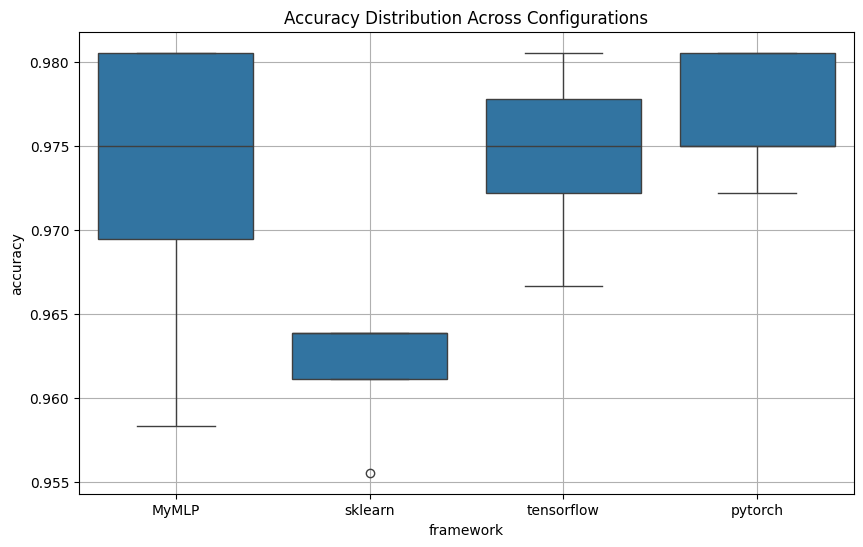

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(

    data=multiclass_results_df,

    x="framework",

    y="accuracy"
)

plt.title(
    "Accuracy Distribution Across Configurations"
)

plt.grid(True)

plt.show()

# Выводы

Итого, сравнив все фреймворки с кастомной реализацией удалось заключить:
1. Кастомная реализаиця работает быстрее других в силу своей легковестности и отсутствия лишней библиотечной логики
2. Кастомная реализация предоставляет такое же качество, что и другие фрейворки, за исключением задачи регрессии
3. В задаче регрессии не удалось достичь качества других фрейворков в силу реализации градиентного спуска